# Section 4 Optional: Solving the Krusell Smith model via SSJ Method

**Issues/Questions? Contact me via maragoneses@g.harvard.edu**

*Expands on Lecture Notes by Ludwig Straub and coauthors*

In this notebook we show how to
1. [Set up a heterogeneous-agent block](#1-hetblock)
2. [Calibrate a model numerically](#2-calibration)
3. [Compute the Jacobian "by hand" as well as automatically](#3-jacobian)
4. [Compute linearized impulse responses](#4-linear)
5. [Estimate shock parameters](#5-estimate)
6. [Compute nonlinear impulse responses](#6-nonlinear)

This notebook accompanies the working paper Auclert, Bardóczy, Rognlie, Straub (2019): "Using the Sequence-Space Jacobian to Solve and Estimate Heterogeneous-Agent Models". Please see the [Github repository](https://github.com/shade-econ/sequence-jacobian) for more information and code.

## Model description

*Firm block:*

As before, the firm block of the model is standard

$$
Y_{t}	= Y_{t}(Z_{t},K_{t-1},L_{t})=Z_{t}K_{t-1}^{\alpha}L_{t}^{1-\alpha}\quad\text{Good Supply}
\\
w_{t}	= w_{t}(Z_{t},K_{t-1},L_{t})=(1-\alpha)Z_{t}\left(\frac{K_{t-1}}{L_{t}}\right)^{\alpha},\quad\text{Labor Demand}
\\
r_{t+1}^{k}= r_{t+1}^{k}(Z_{t+1},K_{t},L_{t+1})= \alpha Z_{t+1}\left(\frac{K_{t}}{L_{t+1}}\right)^{\alpha-1}\quad\text{Asset/Capital Demand chosen at t}
\\
r_{t}^{k}=r_{t}^{k}(Z_{t},K_{t-1},L_{t})=\alpha Z_{t}\left(\frac{K_{t-1}}{L_{t}}\right)^{\alpha-1}\quad\text{Asset/Capital Demand chosen at t-1}
\\
D_{t} = Y_{t} - w_{t}L_{t} - r_{t-1}K_{t-1} = 0  \quad\text{Zero Profits}
\\
1+ r_{t+1}^{k} = 1 + r_{t+1} + \delta   \quad\text{No Arbitrage in Capital Markets}
$$

As before, we are able to recover some steady state values calibrating $\beta$ to get $r = 1%$ and $Z$ and the stochastic process parameters to get $Y=L=1$ in the steady state.

$$
r^{k}=r+\delta
\\
\frac{r^{k}}{\alpha}=Z\left(K\right)^{\alpha-1}=\left(K\right)^{-1}\implies K=\frac{\alpha}{r^{k}}
\\
Z=K^{-\alpha}=\left(\frac{r^{k}}{\alpha}\right)^{\alpha}, \implies Y=ZK^{\alpha}=\left(\frac{r^{k}}{\alpha}\right)^{\alpha}\left(\frac{\alpha}{r^{k}}\right)^{\alpha}=1
\\
w=(1-\alpha)Z\left(K\right)^{\alpha}=(1-\alpha)
$$

Unlike before, we are going to clear Goods Markets by Walras Law, but keep the Euler equation. Unlike in the REP RBC model, we won't get a simple relation between $1=\beta(1+r)$ since due to some of the constraints binding and due to precautionary savings among those currently unconstrained. 

As a quick reminder, it can be written in sequence space as

$$
\textbf{H}_t(\textbf{U}, Z) \equiv 
\begin{pmatrix}
%Y_t - Z_t K_t^\alpha L^{1-\alpha}
%\\
r_t + \delta - \alpha Z_t \left(\frac{K_{t-1}}{L_t}\right)^{\alpha-1} 
\\
w_t - (1-\alpha) Z_t \left(\frac{K_{t-1}}{L_t}\right)^{\alpha}
\\
L_t - \sum_e \pi(e) e
\\
\mathcal{K}_t(\{r_s, w_s\}) - K_t
\end{pmatrix}
= \begin{pmatrix}  0 \\ 0 \\ 0 \\ 0\end{pmatrix},
\qquad t = 0, 1, \dots
$$

where the (aggregate) endogenous variables are $\textbf{U} = (K, L, r, w)$ and the only exogenous variable is $Z$. Let's normalize $\sum_e \pi(e) e = 1$ without loss of generality.

This amounts to assume that household labor supply is exogenous (inelastic). While ideosyncratic labor supply fluctuates, on aggregate, it stays constant. Given this normalization

$$
w_{t}	= w_{t}(Z_{t},K_{t-1},1)=(1-\alpha)Z_{t}\left(K_{t-1}\right)^{\alpha},\quad\text{Labor Demand}
\\
Y_{t}	= Y_{t}(Z_{t},K_{t-1},1)=Z_{t}K_{t-1}^{\alpha}\quad\text{Good Supply}
$$

*Household block:*

The capital function $\mathcal{K}$ follows from the household block characterized by a Bellman equation

$$
\begin{align}
V_t(e, k_{-}) = \max_{c, k} &\left\{\frac{c^{1-\sigma}}{1-\sigma} + \beta \sum_{e'}V_{t+1}(e', k) \mathcal{P}(e, e') \right\}
\\
c + k &= (1 + r_t)k_{-} + w e 
\\
k &\geq 0
\end{align}
$$

Households fluctuate in their labor income (i.e. effective labor supply) via $\mathcal{P}(e, e')$ yielding policy functions ${c=c_{t}^{*}\left(e,k_{-}\right)},{k=k_{t}^{*}\left(e,k_{-}\right)}$

We can represent this model as a simple Directed Acyclic Graph in just 1 unknown $K$ and 1 target, asset market clearing:

![Directed Acyclical Graph](figures/ks_dag.png) 

and write it as

$$
H_t(K, Z) \equiv \mathcal{K}_t\left(\left\{\alpha Z_s K_{s-1}^{\alpha-1} - \delta, (1-\alpha) Z_s K_{s-1}^{\alpha}\right\}\right) - K_t = 0.
$$

Why is this different from the outcome from the Rep Agent model? Note that for unconstrained agents 

$$c_{i,t}   = w_{t}e + (1+r_{t})a_{i,t-1} - a_{i,t} $$
$$c_{i,t+1} = w_{t+1}e' + (1+r_{t+1})a_{i,t}  - a_{i,t+1}$$

and choose $a_{i,t} = a(e,a_{-})$ recursively such that

$$u'(c_{i,t})=\beta\left(1+r_{t+1}\right)\sum_{e^{\prime}}u'\left(c_{i,t+1}\right)P\left(e,e^{\prime}\right)$$
$$c_{i,t}=(\beta\left(1+r_{t+1}\right))^{-(1/\sigma)}\left(\sum_{e^{\prime}}\left(c_{i,t+1}\right)^{-\sigma}P\left(e,e^{\prime}\right)\right)^{-1/\sigma}$$


Where $l_{i,t} = e(i,t)$ while constrained agents cannot borrow $ a_{i,t} \ge 0$ so that 

$$c_{i,t} = w_{t}e + (1+r_{t})a_{i,t-1}$$
$$c_{i,t+1} = w_{t+1}e'$$

So that their Euler equation is slack

$$u'(c_{i,t}) < \beta\left(1+r_{t+1}\right)\sum_{e^{\prime}}u'\left(c_{i,t+1}\right)P\left(e,e^{\prime}\right)$$

Thus, even unconstrained agents anticipate that in a future period, they could be unconstrained and face low consumption, which would make them want to consume less today, and save more. 









## 0 Import packages
The first five are standard python packages, the rest contain code we wrote for this project. 

In [2]:
import numpy as np
from numba import njit
import scipy.optimize as opt
import scipy.linalg as linalg
import matplotlib.pyplot as plt

# We have worked with these before
import utils
import simple_block as sim
from simple_block import simple
import jacobian as jac
import nonlinear

# There are three new packages: 
import het_block as ha
from het_block import het
import krusell_smith as ks
import estimation as est

<a id="1-hetblock"></a>

## 1 Set up heterogeneous-agent block

We start by solving a perfect foresight equilibrium. To do so, we iterate backwards on the value function of agents given deterministic paths of Z and all aggregates, solve for the policy functions on a grid of the state space  given the future, and then iterate forward on the distribution taken as given the entire path of the policy functions. 

The main task here is to write a **backward iteration function** that represents the Bellman equation. This has to be a single step of an *iterative solution method* such as value function iteration that solves for optimal policy on a grid. For the standard income fluctuation problem we're dealing with here, the endogenous gridpoint method of [Carroll (2006)](https://www.sciencedirect.com/science/article/pii/S0165176505003368) is the best practice. 

### Solving Value or Policy Function via Backward Iteration 

Once we have the backward iteration function, we can use the decorator `@het` to turn it into a HetBlock. All we have to do is specify
1. the transition matrix for exogenous states `exogenous` , applying a $P(e,e')$ operator to V or V'. 
2. the policy corresponding to the endogenous state(s) `policy` (currently up to two states), here $a(e,a_{-})$.
3. the backward variable `backward` on which we're iterating (here the first derivative `Va` of the value function with respect to assets)

### Endogenous Gridpoint Method (EGM) $\approx$ Policy Function Iteration

Typically, you work with a current state and try to find the next period's state by optimizing. The nice thing about EGM is essentially that it works really well with backward induction in the consumption problem. Since we are going to be taking as given policies in the steady state at the "end of time", we can work backwards with these policies until we reach the "beginning of time". 

First, note that the EGM method only works with standard income fluctuations problems. For more complicated problems, including those in firm dynamics, you are better off learning other methods. Brute-force grid search always works but it's slow because it requires using a fine grid. For something people actually use, I recommend a method that relies on interpolation, such as "collocation", which permits a coarser grid but requires you to learn about Newton-Rhapson. 

Let the optimal investment policy we are after be $a'=g(e,a_{-})$. Given such policy, the comsumption policy

$$c(e,a_{-}) = we + (1+r)a_{-} - g(e,a_{-}) $$

Typically, when faced with a shock $e$, we think of the agent taking $a_{-}$ as given and solving for $a'=g(e,a_{-})$. That is achieved setting up a grid for $(e,a_{-})$. The EGM does the opposite: it takes as given $a'$ and tries to find the $a_{-}$ stock of assets today that delivers $a'$ if the agent gets the shock e. 

With EGM, we assume that a' is known instead. You can read this as: we are setting up a grid over $(e,a')$. 

Take a *guess of the savings policy function* $g(.,.)$ and the value in the future $g(e',a')$ given known a' (as well as it's value chosen in the present g(a,e) = a'). Then, we can use the Euler equation to back out implied consumption, even without knowing a.  

$$c(e,a_{-})=\left(\beta (1+r) \mathbb{E}_{e^{\prime}}\left[\left((1+r) a'+e^{\prime}-g\left(a', e^{\prime}\right)\right)^{-\sigma}\right]\right)^{-1/\sigma}$$

Given that we have guessed such policy g(.,.), we can back out implied assets that satisfy the constraint

$$a_{-} = \frac{1}{(1+r)} \left(c(e,a_{-}) - we + a'\right)  $$

Naturally, if $a_{-}$ < 0 it must be that the constraint, given realized e, doesn't hold for the original $a'$, and thus, we'd need to lower a'. If $a_{-} < 0 $   even for $a' = 0$, it must be that the agent is constrained. 

Most importantly, this means that our guess for the policy $g(.,.)$ is the one that mapps $(e,a_{-})\rightarrow a' = g(e,a_{-})$ successfully. 

Note that for most models used in economics, given $\bar{e}, g(a,\bar{e})$ is weakly increasing in $a$: the richer you are, the more you can save, and if you're very poor and you can't save at all, $g(a,\bar{e}) = 0$, hence the weak monotonicity. 

Naturally, the grid over $a'$ will need to start at 0, since an agent cannot borrow less than zero. 

Further, we can pick an $a_{max}$ and check later whether it worked or not. 

Let $A$ be a grid over $(a)$ which monotonically increases between $[0,a_{max}]$. Let $M$ size $N_{a},N_{e}$ be a matrix representing the current savings values implied by each of the (given) savings and current shock. This has the interpretation of $A(a) = g(M(a,e),e)$. 

Naturally, the first entry $M(0,e) = 0$ for any $e$. 

Typically, people use an interpolation similar to collocation methods for value functions to approximate g with parameters to guess and loop through in the vector $\theta: g(a, e ; \theta) \approx \theta_{a}a+\theta_{e}e +  \theta_{ae}ae + ... $

Given such $\Theta$, we can solve for consumption at any point as 

$$c(e,a_{-}) = we + (1+r)a_{-} - g(e,a_{-};\Theta) $$

*Final Version*

Households have an exogenous income process (think $z_{t}=w_{t}e_{t}$) and liquid bonds $b\in[0,\infty)$ with a borrowing constriant

$$z\in\left\{ z_{1},\ldots,z_{m}\right\} $$

$$\begin{array}{rl}
V_{t}\left(z_{t},b_{t-1}\right)=\max_{b_{t},a_{t}} & u\left(z_{t}+\left(1+r_{t}^{b}\right)b_{t-1}-b_{t}\right)\\
 & +\lambda_{t}\left(b_{t}-\underline{b}\right)+\beta\mathbb{E}V_{t+1}\left(z_{t+1},b_{t}\right)
\end{array}$$

The FOC

$$u^{\prime}\left(c_{t}\right)=\lambda_{t}+\beta\mathbb{E}\partial_{b}V_{t+1}\left(z_{t+1},b_{t}\right)$$

while the envelope condition 

$$\partial_{b}V_{t}\left(z_{t},b_{t-1}\right)=\left(1+r_{t}^{b}\right)u^{\prime}\left(c_{t}\right)$$

Define the conditional (post-decision) ex-ante (pre-uncertainty) value function

$$W_{t}\left(z_{t},b_{t},a_{t}\right)\equiv\beta\mathbb{E}_{t}V_{t+1}\left(z_{t},b_{t},a_{t}\right)$$

where it's partial is what's on the RHS of the Euler equation. 

Algorithm. Start from a guess for the (discretized) partials of the value function and iterate backward until convergence. 

1. Guess next period's value function: $V_{a}^{0}\left(z^{\prime},b^{\prime}\right)$ over the grid of $\left(z^{\prime},b^{\prime}\right)$

2. $z^{\prime}\rightarrow z$: For any z, we can define the expected value function applying the $\Pi$ operator 

$$W_{b}\left(z,b^{\prime}\right)=\beta\Pi V_{b}^{0}\left(z^{\prime},b^{\prime}\right)$$

3. Unconstrained. Assume the constraint does not bind: $\lambda_{t}=0$

$$u^{\prime}\left(c\right)=W_{b}\left(z,b^{\prime}\right)$$

(a) Consumption needs to be 

$$c\left(z,b^{\prime}\right)=W_{b}\left(z,b^{\prime}\right)^{-\frac{1}{\sigma}}$$

(b) Compute implied savings today $b\left(z,b^{\prime}\right)$

$$b\left(z,b^{\prime}\right)=\frac{c\left(z,b^{\prime}\right)+b^{\prime}-z}{1+r^{b}}$$

(c) We can then invert this function via interpolation with weights \theta to get the implied policy 

$$b^{\prime}(z,b)\implies c\left(z,b^{\prime}(z,b)\right)$$

4. Constrained. Assume the constraint does bind: $\lambda_{t}>0$ so that consumption can be computed from the budget constraint since 

$$
b\left(z,b^{\prime}\right)=\underline{b}
\\
c(z,b)=z+\left(1+r^{b}\right)b-\underline{b}
$$
5. Max. Final b' is the elementwise max of constrained and unconstrained, and consumption follows directly 

$$
b^{\prime}(z,b)=\max\left\{ b_{U}^{\prime}(z,b),b_{C}^{\prime}(z,b)\right\} 
\\
c(z,b)=z+\left(1+r^{b}\right)b-b^{\prime}(z,b)
$$

6. Updating. Given consumption, we can get a new guess for 

$$V_{b}^{1}(z,b)=\left(1+r^{b}\right)c(z,b)^{-\sigma}$$

7. Check whether $V_{b}^{1}\left(z^{\prime},b^{\prime}\right)\approx V_{b}^{0}\left(z^{\prime},b^{\prime}\right)$, and if not, repeat from step 2 until convergence

$$W_{b}\left(z,b^{\prime}\right)	=\beta\Pi V_{b}^{1}\left(z^{\prime},b^{\prime}\right)$$
	...

...

Important: mostly certainly, the value of $b'(z,b)$ implied by this algorithm will not fall into the original grid for bonds b, say $B=[0,b_{max}]$, nor on the overall grid over the two states $M=[0,b_{max}]x[e_{min},e{max}]$. Hence, we need to interpolate whatever policy we get into the existing grid by projecting it, getting the coefficients, and interpolating. 

### Collapsing Grid Trick

One way to do capture a grid of two state variables is with a matrix of $(N_{e},N_{a})$ size or a higher dimensional object with more states, and define any matrix $X(:,:)$ over it. Alternatively, a more tractable object to work with is an array, or a single vector, of size ($N_{e}*N_{a}$) defining a vector over it as $X(:)$. We can always transform one into the other by reshaping this array.  



In [27]:
# This is a crucial step that always shows up, so let's do it slowly

a_grid = np.arange(3)
e_grid = np.arange(2)

print(e_grid), print(a_grid)

# Create new (row) axes for a and (col) axis for e to accomodate the other state var
print(a_grid[np.newaxis, :])
print(e_grid[:,np.newaxis]) 

# The matrix of cash on hand of an agent is simply
r = 0.1
w = 2
coh = w*e_grid[: , np.newaxis] + (1+r)*a_grid[np.newaxis, :]
print(coh)


[0 1]
[0 1 2]
[[0 1 2]]
[[0]
 [1]]
[[0.  1.1 2.2]
 [2.  3.1 4.2]]


In [26]:
# interpolate_y(x, xq, y, yq)
    # x  : array (n), ascending data points
    # xq : array (nq), ascending query points at which we need a yq assigned 
    # y  : array (n), data points
    # returns yq : array (nq), interpolated points (if not specified, it'll be returned):  interpolate_y(x, xq, y)
    
# yq interpolates y onto xq by assingning x to each xq points (requires monotonicity)

a_grid_off = a_grid*1.1
a_grid_off

yq = utils.interpolate_y(x, xq, y)
    


array([0. , 1.1, 2.2])

Typically, which you may be used to from 1st year, we would write a VFI code that takes as given 
- a grid
- e grid
- exog transition

Make a guess for V0(e,a) and solve for a new guess V0(e,a)
$$V_{1} =  u(-a'(e,a) + (1+r)a + we) + \beta \: \Pi \: V0(e',a'(e,a)) $$ 
Delivering also optimal policies that maximize the RHS a'(e,a) and c(e,a), and delivering the solution converging on $V$.

Alternatively, we are going to work on a version of policy function iteration, which takes as given a' to find optimal c
$$ c = u'^{-1}\left(\beta \:\Pi \: V_{a0}(e',a')\right) $$ 

In general, we know the amount of total funds (cash on hand) an agent has to allocate between consumption and savings.
$$z(e,a) = (1+r)a + we$$

And then, all we need to do is use the optimal c to find a' since
$$c + a' = z$$ 

The main issue is that c implies a savings policy $a' = z - c$ that lives off the grid. To paste it back in the grid, we need to make sure to find an $a'(e,a)$ on the grid that is to the grid's $z(e,a) (= c + a')$ what each a' on the grid is to z. Since the grid for a' is the same as the grid for a (careful: won't be the case for firms dynamics), we are set. 

Once we get optimal $a'(e,a)$ and $c(e,a)$ on the grid, we get a new value for the derivative $V_{a1} = (1 + r)c(e,a)^{ -1/\sigma}$ and iterate until $V_{a}$ converges. 


In [304]:
# @het calls class HetBlock: """Initializer for HetBlock, intended to be called via @het() decorator on back it function."""
@het(exogenous='Pi', policy='a', backward='Va')
def household(Va_p, Pi_p, a_grid, e_grid, r, w, beta, eis):
    """Single backward iteration step using endogenous gridpoint method for households with CRRA utility.

    Parameters/Inputs
    ----------   
    Va_p     : array (S*A), t+1's marginal value of assets: Vb_p(z',b') in section notes -- we are guessing it

    Pi_p     : array (S*S), t+1's Markov matrix for skills: Note that W = (beta*Pi_p)*Vb_p(z',b')
    a_grid   : array (A), 1D asset grid
    e_grid   : array (A), 1D skill grid
    r        : scalar, ex-post real interest rate
    w        : scalar, wage
    beta     : scalar, discount rate today
    eis      : scalar, elasticity of intertemporal substitution (1/sigma)

    Returns/Outputs
    ----------
    Va : array (S*A), t's marginal value of assets 
    a  : array (S*A), t's asset policy 
    c  : array (S*A), t's consumption policy
    """
    # Marginal utility of consumption today taking an expected value S*S @ S*A -> S*A (e,a)
    uc_nextgrid = (beta * Pi_p) @ Va_p
    
    # Implied consumption. Note consumption is of dymension S*A
    c_nextgrid = uc_nextgrid ** (-eis)
    
    # Cash on Hand(e,a). Need to create a general xq = we + (1+r)a on the grid 
    coh = w * e_grid[:, np.newaxis] + (1 + r) * a_grid[np.newaxis, :] 
    
    # Since x = c + b' is off the grid (because of c, while b' and b use the same grid)
    # Here we are saying general y = a_grid = b' is to x =  c + b' = c + a_grid, what yq is to xq = coh 
        # yq = utils.interpolate_y(x, xq, y)
    a = utils.interpolate_y(c_nextgrid + a_grid, coh, a_grid)
    
    # armed with a'(e,a_), we need to make sure that savings is constrained at the borrowing constrained
    # equivalent to a' = min(a,0)
    utils.setmin(a, a_grid[0])
    
    # Given coh(e,a_), and policy a'(e,a_) we can back out consumption residually
    c = coh - a
    
    # Return a new guess for Va. Notice that we are doing this in the current period with r(t-1)
    Va = (1 + r) * c ** (-1 / eis)
    
    return Va, a, c

In [31]:
print(type(household))

<class 'het_block.HetBlock'>


As its name suggests, HetBlock is a general class of heterogeneous-agent blocks that comes with useful methods, such as 
- solving for steady-state policy functions by iteration: a(e,a_) and c(e,a_) 
- updating the distribution of agents across states using these policy rules interpolated against a grid: since we are interested on inverting policy rules for assets, where does an agent with $a'=a'(a,e)$ come from? $a = a'^{-1}(a',e)$ since, as we will see, this is crucial for getting the law of motion of the distribution of agents
$${D_{t+1}\left(e^{\prime},K\right)=\sum_{e\in\mathcal{E}}D_{t}\left(e,k_{t}^{*-1}(e,K)\right)P\left(e,e^{\prime}\right)}$$
- computing/storing Jacobians. 

We are going to cover the the most important methods in this notebook.

### Het Block

Note seed = initial guess.

`@het` contains the following functions

        - ss    : do backward and forward iteration until convergence to get complete steady state
        - td    : do backward and forward iteration up to T to compute dynamics given some shocks
        - jac   : compute jacobians of outputs with respect to shocked inputs, using fake news algorithm
        - ajac  : compute asymptotic columns of jacobians output by jac, also using fake news algorithm

Where `ss` is defined by

    def ss(self, backward_tol=1E-8, backward_maxit=5000, forward_tol=1E-10, forward_maxit=100_000, **kwargs)
    
This has the following required inputs


                - The exogenous Markov matrix, e.g. Pi=... if self.exogenous=='Pi'
                - A seed for each backward variable, e.g. Va=... and Vb=... if self.backward==('Va','Vb')
                - A grid for each policy variable, e.g. a_grid=... and b_grid=... if self.policy==('a','b')
                - All other inputs to the backward iteration function self.back_step_fun, except _p added to
                    for self.exogenous and self.backward, for which the method uses steady-state values.
                    If there is a self.hetinput, then we need the inputs to that, not to self.back_step_fun.
                    
Hence why we need to specify all this here: `@het(exogenous='Pi', policy='a', backward='Va')`  

                - A seed for the distribution: D=...
                - If no seed for the distribution is provided, a seed for the invariant distribution
                    of the Markov process, e.g. Pi_seed=... if self.exogenous=='Pi'
                    
In essence, this function does the following

1. Run backward iteration to solve ss policies through policy/value function backward induction til convergence

        sspol = self.policy_ss(kwargs, backward_tol, backward_maxit)
        
        ...
        
        for it in range(maxit):
            try:
                # run and store results of backward iteration, which come as tuple, in dict
                sspol = {k: v for k, v in zip(self.all_outputs_order, self.back_step_fun(**ssin))}
            except KeyError as e:
                print(f'Missing input {e} to {self.back_step_fun.__name__}!')
                raise

            # only check convergence every 10 iterations for efficiency
            if it % 10 == 1 and all(utils.within_tolerance(sspol[k], old[k], tol) for k in self.policy):
                break

            # update 'old' for comparison during next iteration, prepare 'ssin' as input for next iteration
            old.update({k: sspol[k] for k in self.policy})
            ssin.update({k + '_p': sspol[k] for k in self.backward})
        else:
            raise ValueError(f'No convergence of policy functions after {maxit} backward iterations!')
        
        # want to record inputs in ssin, but remove _p, add in hetinput inputs if there
        for k in self.inputs_p:
            ssin[k] = ssin[k + '_p']
            del ssin[k + '_p']
        if self.hetinput is not None:
            for k in self.hetinput_inputs:
                if k in original_ssin:
                    ssin[k] = original_ssin[k]
        
        # returns dictionary with ss inputs and policies
        return {**ssin, **sspol}
        
2. Run forward iteration to solve for the distribution taking as given ss policies

        D = self.dist_ss(Pi, sspol, grid, forward_tol, forward_maxit, D_seed, pi_seed)

        ...
        
        # first obtain initial distribution D
        if D_seed is None:
            # compute stationary distribution for exogenous variable
            pi = utils.stationary(Pi, pi_seed)
            
            # now initialize full distribution with this, assuming uniform distribution on endogenous vars
            endogenous_dims = [grid[k].shape[0] for k in self.policy]
            D = np.tile(pi, endogenous_dims[::-1] + [1]).T / np.prod(endogenous_dims)
        else:
            D = D_seed

        # obtain interpolated policy rule for each dimension of endogenous policy
        sspol_i = {}
        sspol_pi = {}
        for pol in self.policy:
            # use robust binary search-based method that only requires grids, not policies, to be monotonic
            sspol_i[pol], sspol_pi[pol] = utils.interpolate_coord_robust(grid[pol], sspol[pol])

        # iterate until convergence by tol, or maxit
        Pi_T = Pi.T.copy()
        for it in range(maxit):
            Dnew = self.forward_step(D, Pi_T, sspol_i, sspol_pi)

            # only check convergence every 10 iterations for efficiency
            if it % 10 == 0 and utils.within_tolerance(D, Dnew, tol):
                break
            D = Dnew
        else:
            raise ValueError(f'No convergence after {maxit} forward iterations!')
        
        return D
        
3. Aggregate all outputs resulting from policies x distribution, and capitalize

        aggs = {k.upper(): np.vdot(D, sspol[k]) for k in self.non_back_outputs}

        return {**sspol, **aggs, 'D': D}



<a id="2-calibration"></a>

## 2 Calibrating the steady state
Next, we calibrate the model in general equilibrium. The calibration exercise amounts to finding the right discount factor $\beta$ to hit a targeted interest rate conditional on all the other exogenous parameters. We use Brent's method, an efficient way to solve for a root on an interval, from the `scipy.optimize` package to do so.

Brent takes the following args
`scipy.optimize.brentq(f, a, b, args=(), xtol=2e-12, rtol=8.881784197001252e-16, maxiter=100, full_output=False, disp=True)`

takes a scalar-valued function `f` and finds it's root ($x$ where $f(x) = 0$) where we are bounding the root to be between the values such that $f(a)<0$ and $f(b)>0$.

This `f(x)` could be anything, for example we could define an $f(x) = x^2 - 1$ 

`def f(x):
     return (x**2 - 1)
   `  
 We can use use lambda to create a new function that passes a value (x) into a richer function fixing all other values and finding `x` where two functions cross `f1(x,p1)-f2(x,p2) = 0`
 
 `def f1(x,p1):
    return - p1*x 
`
`
def f2(x,p2):
    return np.log(p2*x)
`
`    
scipy.optimize.brentq(lambda x: f1(x,p1)-f2(x,p2), a, b)
`
 
 `x = opt.brentq(lambda x: f(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis, Va=Va)['A'] - K, beta_min, beta_max, full_output=True)`

In our case, this is going to take the form 

`beta = opt.brentq(lambda x: household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis, Va=Va)['A'] - K, beta_min, beta_max, full_output=True)`


Although additional efficiency gains would be possible here (for instance, by updating our initial guesses for policy and distribution along the way), we will not implement them, since they are not our focus here.

Our default values depart slightly from the canonical Krusell-Smith calibration, mainly by assuming a 7-state income process (more risk) and a lower capital share. More risk increases the precautionary savings motive, while less capital limits the ability to self-insure (since there isn't enough capital demand to justify high savings, thus, agents will tend to have lower savings). These changes lead to higher MPCs and less RA-like behavior.

The notice that the first force, higher savings supply will tend to depress interest rates. In constrast, lower capial demand will tend to increase them. 

Of note, we are starting off with default grid-sizes of (7,500)  and a $a_{max}=200$

### Discretized AR(1) shock process

Also of note, we are using a standard Rouwenhorst to discretize a continuous AR(1) pricess with calibrated persistence and variance to a discrete Markov one that is forced to switch between nS states following a transition matrix. Both the resulting grid and transition matrix will be provided by the algorithm. 

`e_grid, pi_s, Pi = utils.markov_rouwenhorst(rho=rho, sigma=sigma, N=nS)`

Note the three key outputs (in order) of markov_rouwenhorst are in logs 

`    y  : array (N), states proportional to exp(s) s.t. E[y] = 1
    pi : array (N), stationary distribution of discretized process
    Pi : array (N*N), Markov matrix for discretized process
`
This means that E(e_grid) = 1 and that the steady state disitrbution of e (given that the transition matrix is independent of economic activity in this simple example) will be pi_s. Pi is a $N*N$ transition matrix that can be applied to calculate both expectations and distributional dynamics. 


In [108]:
rho  =0.966
sigma=0.5
nS    =3

e_grid, pi_s, Pi = utils.markov_rouwenhorst(rho=rho, sigma=sigma, N=nS)

print(e_grid)

print(pi_s)

sum(pi_s)

print(Pi)

# sum over cols
print(Pi.sum(axis=0)) 

# sum over rows
print(Pi.sum(axis=1))

# This tells us that we should read the rows in a given column as 
# P(e,e') probability of ending in row-state e' given that you start from col state e (CHECK)


[0.43622974 0.88472407 1.79432213]
[0.25 0.5  0.25]
[[9.66289e-01 3.34220e-02 2.89000e-04]
 [1.67110e-02 9.66578e-01 1.67110e-02]
 [2.89000e-04 3.34220e-02 9.66289e-01]]
[0.983289 1.033422 0.983289]
[1. 1. 1.]


In [111]:
# Note it's not a uniform grid in levels, rather one that is equidistant in logs (often known as a log-grid)

nA  =4
amax=100

a_grid = utils.agrid(amax=amax, n=nA)
print(a_grid)

[  0.           1.59354949  13.34469882 100.        ]


In [112]:
a_grid = utils.agrid(amax=amax, n=nA)
e_grid, pi_s, Pi = utils.markov_rouwenhorst(rho=rho, sigma=sigma, N=nS)
    
r=0.01 
eis=1
alpha = 0.11
w = 1-alpha

coh = (1 + r) * a_grid[np.newaxis, :] + w * e_grid[:, np.newaxis]
Va = (1 + r) * (0.1 * coh) ** (-1 / eis)

def f(x):

    return household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis,Va=Va)

# Households contains a dictionary with all the inputs we fed 
f(0.89)
# as well as all endogenous variables a(e,a_) where this is a Ns,Na 2D array


{'r': 0.01,
 'w': 0.89,
 'eis': 1,
 'beta': 0.89,
 'a_grid': array([  0.        ,   1.59354949,  13.34469882, 100.        ]),
 'e_grid': array([0.43622974, 0.88472407, 1.79432213]),
 'Va': array([[2.60145369, 1.31434702, 0.42375073, 0.08131261],
        [1.28269537, 0.81933622, 0.3415007 , 0.0768809 ],
        [0.63245693, 0.47795536, 0.25420237, 0.07042339]]),
 'Pi': array([[9.66289e-01, 3.34220e-02, 2.89000e-04],
        [1.67110e-02, 9.66578e-01, 1.67110e-02],
        [2.89000e-04, 3.34220e-02, 9.66289e-01]]),
 'a': array([[ 0.        ,  1.22928703, 11.48291354, 88.96704748],
        [ 0.        ,  1.16418422, 11.30801606, 88.65020183],
        [ 0.        ,  1.0932636 , 11.10188016, 88.25512113]]),
 'c': array([[ 0.38824447,  0.76844242,  2.38347673, 12.42119698],
        [ 0.78740442,  1.23270518,  2.95753416, 13.13720259],
        [ 1.5969467 ,  2.11316808,  3.97321234, 14.34182556]]),
 'C': 0.8900000037377717,
 'A': 2.32175900882093e-08,
 'D': array([[2.49999999e-01, 2.71172856e

In [119]:
def a_policy(x):

    return household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis,Va=Va)['a']

def a_aggregate(x):

    return household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis,Va=Va)['A']

def k_aggregate(x):

    return household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis,Va=Va)['K']

def distribution(x):

    return household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis,Va=Va)['D']

# Households contains a dictionary with all the inputs we fed 
print('a(e,a_) = ')
print(a_policy(0.89))
# as well as all endogenous variables a(e,a_) where this is a Ns,Na 2D array
print('A = sum(a(e,a_)) = ')
print(a_aggregate(0.89))
# We can also obtain the stationary distribution
print('D(e,a_) = ')
print(distribution(0.89))


a(e,a_) = 
[[ 0.          1.22928703 11.48291354 88.96704748]
 [ 0.          1.16418422 11.30801606 88.65020183]
 [ 0.          1.0932636  11.10188016 88.25512113]]
A = sum(a(e,a_)) = 
2.32175900882093e-08
D(e,a_) = 
[[2.49999999e-01 2.71172856e-10 1.84934505e-10 5.05935790e-11]
 [4.99999999e-01 3.59958317e-10 2.82101748e-10 8.93063693e-11]
 [2.50000000e-01 1.20253311e-10 1.05789534e-10 3.88358730e-11]]


Recall all we needed to chose is $(K,L,r,w)$ in the stationary equilibrium with $Z$ such that $Y=1$. Since $L=1$ and $Y=1$ implies that $(K,L,W)$ are known, for the pourpose of the calibration all we have to do is find the interest $\beta$ such that 

$$ \beta\quad s.t.\quad H(\beta) = A(r(\beta),K,L,w)) - K = 0$$

In [131]:
def H(x):
    
    K = 0.1 +  a_aggregate(x)

    return a_aggregate(x) - K

print(H(0.89))



-0.1


In [2]:
def ks_ss(lb=0.98, ub=0.999, r=0.01, eis=1, delta=0.025, alpha=0.11, rho=0.966, sigma=0.5, nS=7, nA=500, amax=200):
    """Solve steady state of full GE model. Calibrate beta to hit target for interest rate.
    
    Parameters
    ----------
    lb    : scalar, lower bound of interval bracketing beta
    ub    : scalar, upper bound of interval bracketing beta
    
    r     : scalar, real interest rate (typically calibrated to 1-2%)
    
    eis   : scalar, elasticity of intertemporal substitution
    delta : scalar, depreciation rate
    alpha : scalar, capital share
    
    rho   : scalar, autocorrelation of income process
    sigma : scalar, cross-sectional sd of log income
    
    nS    : int, number of income gridpoints
    nA    : int, number of capital gridpoints
    amax  : scalar, upper bound of capital grid

    Returns
    ----------
    ss : dict, steady state values
    """
    # set up grid
    a_grid = utils.agrid(amax=amax, n=nA)
    e_grid, pi_s, Pi = utils.markov_rouwenhorst(rho=rho, sigma=sigma, N=nS)
    
    # solve analytically what we can
    rk = r + delta
    Z = (rk / alpha) ** alpha  # normalize so that Y=1
    K = (alpha * Z / rk) ** (1 / (1 - alpha))
    Y = Z * K ** alpha # should give 1 
    w = (1 - alpha) * Z * (alpha * Z / rk) ** (alpha / (1 - alpha)) # should give 1-\alpha
    
    # prefill grid for cash-on-hand as we did above: z(e,a) = (1+r)a + we blowing up the a,e grids to accomodate
    coh = (1 + r) * a_grid[np.newaxis, :] + w * e_grid[:, np.newaxis]
    
    # initialize guess for policy function iteration as if c = 0.1z (or a' = 0.9z), an MPC splot of 0.1. 
    Va = (1 + r) * (0.1 * coh) ** (-1 / eis)

    # Given Va, we can solve for aggregate equilibrium savings 
    
    # solve for beta
    beta_min = lb / (1 + r)
    beta_max = ub / (1 + r)
    beta, sol = opt.brentq(lambda x: \
                          household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis,Va=Va)['A'] \
                          - K \
                           , beta_min, beta_max, full_output=True)
    if not sol.converged:
        raise ValueError('Steady-state solver did not converge.')

    # extra evaluation for reporting
    ss = household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=beta, eis=eis, Va=Va)
    
    # check Walras's law
    walras = Y - ss['C'] - delta * K
    assert np.abs(walras) < 1E-8
    
    # add aggregate variables
    ss.update({'w': w, 'Z': Z, 'K': K, 'L': 1, 'Y': Y, 'alpha': alpha, 'delta': delta, 'walras': walras, 'pi_s': pi_s})

    return ss

In [216]:
ss = ks_ss()

ss

{'r': 0.01,
 'w': 0.8900000000000001,
 'eis': 1,
 'beta': 0.9819527880123727,
 'a_grid': array([0.00000000e+00, 3.37217033e-03, 6.78982679e-03, 1.02535829e-02,
        1.37640606e-02, 1.73218899e-02, 2.09277097e-02, 2.45821672e-02,
        2.82859186e-02, 3.20396287e-02, 3.58439713e-02, 3.96996296e-02,
        4.36072956e-02, 4.75676708e-02, 5.15814663e-02, 5.56494026e-02,
        5.97722100e-02, 6.39506286e-02, 6.81854086e-02, 7.24773101e-02,
        7.68271038e-02, 8.12355704e-02, 8.57035015e-02, 9.02316990e-02,
        9.48209760e-02, 9.94721563e-02, 1.04186075e-01, 1.08963578e-01,
        1.13805523e-01, 1.18712780e-01, 1.23686229e-01, 1.28726764e-01,
        1.33835288e-01, 1.39012720e-01, 1.44259989e-01, 1.49578036e-01,
        1.54967817e-01, 1.60430299e-01, 1.65966462e-01, 1.71577301e-01,
        1.77263823e-01, 1.83027049e-01, 1.88868013e-01, 1.94787763e-01,
        2.00787364e-01, 2.06867891e-01, 2.13030436e-01, 2.19276106e-01,
        2.25606022e-01, 2.32021320e-01, 2.385231

Notice the use of `household.ss` to evaluate steady-state asset demand for given inputs. This is the first HetBlock method we see in action.

Let's solve for the steady state using our default calibration, and plot the consumption policy function for all skill types  as a function of assets.

In [339]:
print(ss['D'].shape)
# Notice the stationary distribution is (nS,nA) sized
print(ss['a'].shape)
print(ss['a'][:, :10].shape)
print(ss['a'][:, :10].T.shape)
print(ss['a_grid'][:10].shape)


(7, 500)
(7, 500)
(7, 10)
(10, 7)
(10,)


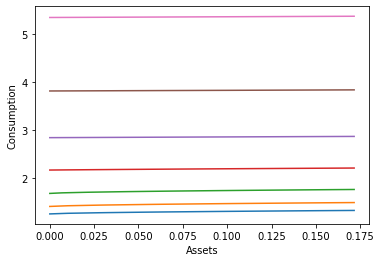

In [167]:
# Plot assets for different e levels for the first 10 levels of assets

plt.plot(ss['a_grid'][:40], np.exp(ss['c'][:, :40]).T)
plt.xlabel('Assets'), plt.ylabel('Consumption')
plt.show()

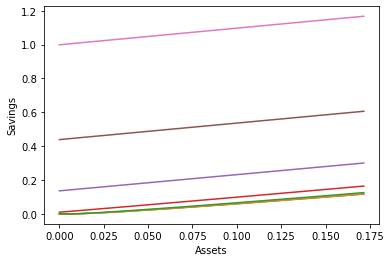

In [180]:
plt.plot(ss['a_grid'][:40], ss['a'][:, :40].T)
plt.xlabel('Assets'), plt.ylabel('Savings')
plt.show()

A static notion of marginal propensity to consume is the share of disposable consumption that is not saved. 

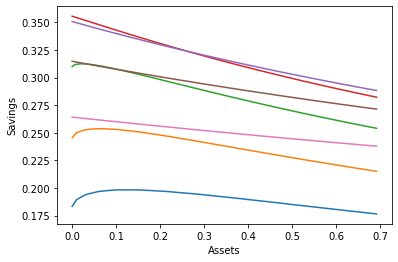

In [184]:
plt.plot(ss['a_grid'][:100], ss['c'][:, :100].T/(ss['a'][:, :100].T +  np.exp(ss['c'][:, :100]).T))
plt.xlabel('Assets'), plt.ylabel('Savings')
plt.show()

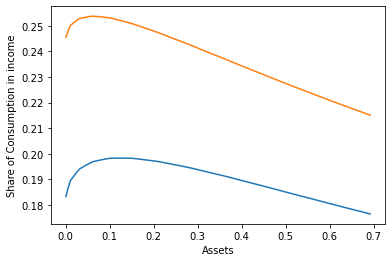

In [191]:
plt.plot(ss['a_grid'][:100], ss['c'][:2, :100].T/(ss['a'][:2, :100].T +  np.exp(ss['c'][:2, :100]).T))
plt.xlabel('Assets'), plt.ylabel('Share of Consumption in income')
plt.show()

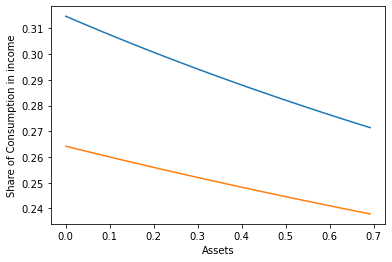

In [193]:
plt.plot(ss['a_grid'][:100], ss['c'][-2:, :100].T/(ss['a'][-2:, :100].T +  np.exp(ss['c'][-2:, :100]).T))
plt.xlabel('Assets'), plt.ylabel('Share of Consumption in income')
plt.show()

In [145]:
ss['c'].shape

(7, 500)

[[1.31353217e-002 5.84480912e-005 5.27129890e-005 ... 7.20666926e-188
  2.01369308e-191 2.84296731e-195]
 [6.91553858e-002 6.10243284e-004 5.15431585e-004 ... 9.46641352e-186
  2.58609191e-189 3.57101407e-193]
 [1.20168671e-001 3.17586624e-003 2.26369958e-003 ... 5.32847935e-184
  1.42991890e-187 1.93985774e-191]
 ...
 [2.08540965e-004 5.63618121e-006 2.37946242e-005 ... 2.77552158e-181
  7.26459524e-185 9.61215786e-189]
 [2.39414999e-006 6.48909694e-008 3.88316774e-007 ... 2.52914992e-180
  6.56218982e-184 8.60682571e-188]
 [1.03247127e-008 2.80321633e-010 2.17181485e-009 ... 9.54341508e-180
  2.45877870e-183 3.20207595e-187]]


(array([312.,  30.,  23.,  17.,  16.,  18.,  14.,  18.,  20.,  32.]),
 array([3.20207595e-187, 1.46430096e-005, 2.92860192e-005, 4.39290287e-005,
        5.85720383e-005, 7.32150479e-005, 8.78580575e-005, 1.02501067e-004,
        1.17144077e-004, 1.31787086e-004, 1.46430096e-004]),
 <BarContainer object of 10 artists>)

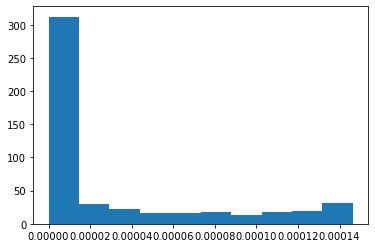

In [201]:
print(ss['D'])
plt.hist(ss['D'][6,:])
# Notice that the people with the best shock are distributed all over the place

(array([370., 109.,   0.,   1.,   4.,   6.,   7.,   1.,   1.,   1.]),
 array([5.73316145e-190, 8.10731422e-004, 1.62146284e-003, 2.43219427e-003,
        3.24292569e-003, 4.05365711e-003, 4.86438853e-003, 5.67511995e-003,
        6.48585137e-003, 7.29658280e-003, 8.10731422e-003]),
 <BarContainer object of 10 artists>)

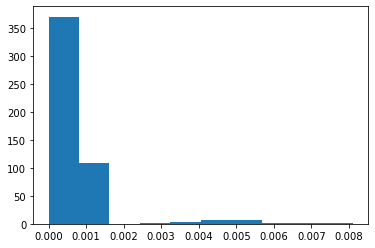

In [203]:
plt.hist(ss['D'][3,:])
# Those with average shocks start getting absorved by the constraint

(array([499.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([3.57101407e-193, 6.91553858e-003, 1.38310772e-002, 2.07466158e-002,
        2.76621543e-002, 3.45776929e-002, 4.14932315e-002, 4.84087701e-002,
        5.53243087e-002, 6.22398473e-002, 6.91553858e-002]),
 <BarContainer object of 10 artists>)

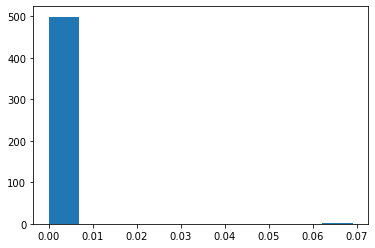

In [205]:
plt.hist(ss['D'][1,:])
# Finally, those with the worst shock are pretty much doomed unless they are extremely wealthy

In [237]:
# Since aggregates do not affect the distribution directly, the marginal for D and the stationary distribution should coincide 
print('No Distance between the Stationary Distribution given by Pi and the Marginal along e')
print(np.sum(ss['D'][:,:],axis = 1))

print(ss['pi_s'])

No Distance between the Stationary Distribution given by Pi and the Marginal along e
[0.015625 0.09375  0.234375 0.3125   0.234375 0.09375  0.015625]
[0.015625 0.09375  0.234375 0.3125   0.234375 0.09375  0.015625]


In [278]:
# A substantial share of households live at the constraint 
print(np.sum(ss['D'][ss['a'] == 0]))
# A majority of households have less than average assets, indicating wealth is extremely concentrated
print(np.sum(ss['D'][ss['a'] < ss['A']]))
# Roughly half of households in this example live with less than 25% of aggregate assets
print(np.sum(ss['D'][ss['a'] < 0.25*ss['A']]))

0.20913577987957946
0.7069885880540927
0.4870282451023628


### Speed of steady-state solution
Our backward and forward iterations use Numba, [a just-in-time compilation library](https://numba.pydata.org/numba-doc/dev/user/5minguide.html) that translates pure numerical Python to fast machine code. The first time functions are run, there is some compilation lag, similar to (but much less time-consuming than) compilation time in languages like C++, Fortran, and Julia.

Now that we have run everything once, we can time our steady-state calibration routine. An efficient steady state is not the focus of this notebook or our methods, but it is nice to see that performance is still quite good:

In [6]:
%time ss = ks_ss()

CPU times: user 646 ms, sys: 5.73 ms, total: 652 ms
Wall time: 651 ms


Indeed, this simple example is so fast that increasing the number of asset gridpoints from 500 to 2000, and thus the total number of states from $7 \times 500=3500$ to $7 \times 2000 = 14000,$ increases computation time by less than a factor of four.

In [7]:
%time _ = ks.ks_ss(nA=2000)

CPU times: user 3.38 s, sys: 49 ms, total: 3.43 s
Wall time: 1.73 s


<a id="3-jacobian"></a>

## 3 Jacobians
Jacobians are the key concept to solve and to estimate models in sequence space. Each model block has its own Jacobians, which can be combined via the chain rule into Jacobians for the complete model. A Jacobian in a $T$-dimensional (truncated) sequence space is a $T \times T$ matrix of the form

$$
\frac{d Y}{d X} = 
\begin{pmatrix}
\frac{d Y_0}{d X_0} & \frac{d Y_0}{d X_1} & \dots & \frac{d Y_0}{d X_T} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{d Y_T}{d X_0} & \frac{d Y_T}{d X_1} & \dots & \frac{d Y_T}{d X_T}
\end{pmatrix}
$$

evaluated at the steady state. Every column can be interpreted as the impulse response to a one-period news shock.

### 3.1 Simple blocks
To build intuition, let's start with the firm block. In our code, simple blocks are specified as regular Python functions with the added decorator ``@simple``. In the body of the function, we directly implement the corresponding equilibrium conditions. The decorator turns the function into an instance of ``SimpleBlock``, a class that, among other things, knows how to handle time displacements such as `K(-1)` to denote 1-period lags and `r(+1)` to denote 1-period leads. In general, one can write (-s) and (+s) to denote s-period lags and leads.

In [289]:
@simple
def firm(K, L, Z, alpha, delta):
    r = alpha * Z * (K(-1) / L) ** (alpha-1) - delta
    w = (1 - alpha) * Z * (K(-1) / L) ** alpha
    Y = Z * K(-1) ** alpha * L ** (1 - alpha)
    return r, w, Y

Recall in the rep agent model we had defined three simple blocks

`@simple
def firm(K, L, Z, alpha, delta):
 ...
    return r, w, Y
@simple
def household(K, L, w, eis, frisch, vphi, delta):
   ...
    return C, I
@simple
def mkt_clearing(r, C, Y, I, K, L, w, eis, beta):
   ...
    return goods_mkt, euler, walras
`

And obtained each of the TxT Jacobians for all UxZ different combos of endog and exog variables

`
G = jac.get_G(block_list = [firm, household, mkt_clearing],
              exogenous  = ['Z'],
              unknowns   = ['K', 'L'],
              targets    = ['euler', 'goods_mkt'],
              T          = 300,
              ss         = ss)`
      
Where the Jacobians linearize the euler and goods_mkt equations around the steady state ss and obtain via the chain rule all IRFs regardless of whether the variable shocked are the original unknowns $U=K,L$ or any other, e.g. $Y = C + K - (1-\delta)K(-)$.  

`G['Y']['Z']`

Now we still have a simple firm block, but the household block is more complicated, with consumption C and assets A coming as a result of aggregating micro-level decissions we have obtained around the steady state

`ks_ss()['A']`
`ks_ss()['C']` 




Simple blocks can compute their Jacobians by using the method `SimpleBlock.jac` As in `jac.get_G` it takes in the steady state dict returned by `ks_ss` and two optional inputs: the truncation horizon $T$ and list of variables to differentiate with respect to. It returns the Jacobians in a nested dict, where the first level is the output variable $Y$ and the second level is the input variable $X$.


In [297]:
J_firm = firm.jac(ss, T=5, shock_list=['K', 'Z'])
print(J_firm['Y']['Z']) # Jacobian of output Y vs. TFP Z
print(J_firm['Y']['K']) # Jacobian of output Y vs. capital X
J_firm

[[1.13424196 0.         0.         0.         0.        ]
 [0.         1.13424196 0.         0.         0.        ]
 [0.         0.         1.13424196 0.         0.        ]
 [0.         0.         0.         1.13424196 0.        ]
 [0.         0.         0.         0.         1.13424196]]
[[0.    0.    0.    0.    0.   ]
 [0.035 0.    0.    0.    0.   ]
 [0.    0.035 0.    0.    0.   ]
 [0.    0.    0.035 0.    0.   ]
 [0.    0.    0.    0.035 0.   ]]


{'r': {'K': array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
         [-0.00991136,  0.        ,  0.        ,  0.        ,  0.        ],
         [ 0.        , -0.00991136,  0.        ,  0.        ,  0.        ],
         [ 0.        ,  0.        , -0.00991136,  0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , -0.00991136,  0.        ]]),
  'Z': array([[0.03969847, 0.        , 0.        , 0.        , 0.        ],
         [0.        , 0.03969847, 0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.03969847, 0.        , 0.        ],
         [0.        , 0.        , 0.        , 0.03969847, 0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.03969847]])},
 'w': {'K': array([[0.     , 0.     , 0.     , 0.     , 0.     ],
         [0.03115, 0.     , 0.     , 0.     , 0.     ],
         [0.     , 0.03115, 0.     , 0.     , 0.     ],
         [0.     , 0.     , 0.03115, 0.     , 0.     ],
         [0

By default, `SimpleBlock.jac` compoutes the Jacobian for each input-output pair. In practice, it only makes sense to do so with respect to endogenous variables and shocks, hence the `shock_list` option. In this model, capital and TFP are the only inputs that will ever change.

The Jacobian is diagonal because the production function does not depend on leads or lags of productivity. Such sparsity is very common for simple blocks, and we wrote the SimpleBlock class to take full advantage of it. For example, if we *leave the truncation parameter $T$ unspecified, which is recommended, `SimpleBlock.jac` returns a more efficient sparse representation of the Jacobian.*

In [301]:
J_firm_sparse = firm.jac(ss, shock_list=['K', 'Z'])
print(J_firm_sparse['Y']['Z'])
print(J_firm_sparse['Y']['K'])
print(J_firm_sparse['r']['Z'])
print(J_firm_sparse['w']['K'])

SimpleSparse({(0, 0): 1.134})
SimpleSparse({(-1, 0): 0.035})
SimpleSparse({(0, 0): 0.040})
SimpleSparse({(-1, 0): 0.031})


The output means that the only non-zero element is 1.134 along the main diagonal.

### 3.2 HA blocks
HA blocks have more complicated (potentially non-sparse) Jacobians, but they have a regular structure that we can exploit to calculate them very quickly. For comprehensive coverage of our **fake news algorithm**, please see the [het-agent Jacobian notebook](het_jacobian.ipynb) as well as the paper.

HetBlocks have a `HetBlock.jac` method that is analogous to `SimpleBlock.jac` above.

Recall that on the firm side, the key inputs were `K,Z` (which spit out `w,r` as outputs) via the `['r']['Z']` and `['w']['Z']`  entries. 
`J_firm = firm.jac(ss, T=5, shock_list=['K', 'Z'])`

On the household side, the key object is aggregate savings 

$$ \mathcal{K}_{t}\left(r_{t},w_{t}\right)=\mathcal{K}_{t}\left(\left\{\alpha Z_{s} K_{s-1}^{\alpha-1}-\delta,(1-\alpha) Z_{s} K_{s-1}^{\alpha}\right\}\right)$$

since these prices are the key determinants of cash-in-hand

$$ z_{t} = w_{t}e + (1+r_{t})a_{-} $$ 

and given $z_{t}$ the split $z_{t} = c_{t} + a_{t}$ is determined by the Euler equation, where E is over z's e.  

$$u'(z_{t} - a_{t}) = \beta (1+r_{t+1})Eu'(z_{t+1} - a_{t+1}))$$ 

Recall the function `household` we defined in the Het Agent Block solves for individual policies given an intial guess. 

` Va, a, c = household(Va_p, Pi_p, a_grid, e_grid, r, w, beta, eis)`


In [305]:
J_ha = household.jac(ss, T=5, shock_list=['r', 'w'])
print(J_ha['C']['r'])
# The dictionary contains all IRFS of C and A (aggregates) wrt each GE input taken as given by households (w,r)
J_ha


[[ 0.09578534 -0.68179015 -0.64119935 -0.60434415 -0.57057436]
 [ 0.09413756  0.13463153 -0.64841526 -0.61133486 -0.5771951 ]
 [ 0.09250592  0.12963223  0.16651935 -0.61980277 -0.58527967]
 [ 0.09087539  0.12509918  0.15952962  0.1938437  -0.59485549]
 [ 0.08926245  0.12116257  0.15312513  0.18541035  0.21770361]]


{'C': {'r': array([[ 0.09578534, -0.68179015, -0.64119935, -0.60434415, -0.57057436],
         [ 0.09413756,  0.13463153, -0.64841526, -0.61133486, -0.5771951 ],
         [ 0.09250592,  0.12963223,  0.16651935, -0.61980277, -0.58527967],
         [ 0.09087539,  0.12509918,  0.15952962,  0.1938437 , -0.59485549],
         [ 0.08926245,  0.12116257,  0.15312513,  0.18541035,  0.21770361]]),
  'w': array([[0.15282058, 0.04608431, 0.04183542, 0.03833594, 0.03533451],
         [0.04595828, 0.14660642, 0.04209953, 0.03875262, 0.03576658],
         [0.04214215, 0.04186114, 0.1428882 , 0.03919626, 0.0363287 ],
         [0.03883823, 0.03908125, 0.03893942, 0.14018943, 0.03692287],
         [0.03620579, 0.03627091, 0.03664599, 0.03664468, 0.13807493]])},
 'A': {'r': array([[3.04707181, 0.68179015, 0.64119935, 0.60434415, 0.57057436],
         [2.98340497, 3.69683367, 1.29602661, 1.22172245, 1.1534752 ],
         [2.9207331 , 3.60416978, 4.28532468, 1.85374245, 1.75028963],
         [2.85906504, 

Notice that this matrix is no longer sparse. This generally the case for HA blocks. *The Bellman equation implies that policies are forward-looking, and then aggregates are also backward-looking due to persistence coming via the distribution.*

Fortunately, our `SimpleSparse` Jacobians play nicely with these full matrices, so that we can easily combine the Jacobians of simple blocks and HA blocks. For example, the multiplication operator `@` maps any combination of SimpleSparse and full matrices into full matrices.   

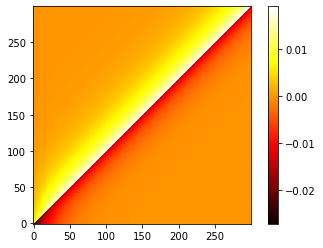

In [335]:
# To know how C changes with Z via r, dCdr drdZ are multiplied by the chain rule.
x = J_ha['C']['r'] @ J_firm_sparse['r']['Z']
plt.imshow(x , cmap='hot',origin="lower", interpolation='nearest')
plt.colorbar()
plt.show()

<a id="4-linear"></a>

## 4 Linearized dynamics using Jacobians
Recall that we reduced the model to a single equation $H$

$$
H_t(K, Z) \equiv \mathcal{K}_t\left(\left\{\alpha Z_s K_{s-1}^{\alpha-1} - \delta, (1-\alpha) Z_s K_{s-1}^{\alpha}\right\}\right) - K_t = 0.
$$

to be solved for $K$ given any $Z$.

This is the composition of the household capital supply function $\mathcal{K}$ with the interest rate  and wage functions that we can obtain from the firm block of the model. 

$r(K_{t-1}, Z_t) = \alpha Z_t K_{t-1}^{\alpha-1} - \delta$

$w(K_{t-1}, Z_t) = (1-\alpha) Z_t K_{t-1}^{\alpha}$ 

We will obtain a linear characterization of all impulse responses in two ways:
1. First, by duly following the notation and algebra of section 2.2 in the paper. This hands-on approach is transparent, but error-prone in all but the simplest cases.
2. Second, by leveraging the powerful convenience functions (simple-blocks and jacobian getters using automatic differentiation) that we introduced in the RBC notebook, and further employ in the one-asset and two-asset HANK notebooks. Throughout this section, we'll use the steady state `ss` we've already solved for, and a 300-period truncation horizon.

For $d \mathbf{Z}=\left(d Z_{0}, d Z_{1}, \ldots,d Z_{T}\right)^{\prime}$ and $\mathbf{H}(\mathbf{K}, \mathbf{Z})=0$

$$H_t(r_{t}(K,Z), w_{t}(K,Z)) \equiv \mathcal{K}_t\left(\left\{r, w\right\}\right) - K_t = 0.$$

$$d \mathbf{K}=-\mathbf{H}_{\mathbf{K}}^{-1} \mathbf{H}_{\mathbf{Z}} d \mathbf{Z}$$

First, the derivative wrt capital

$$\left[\mathbf{H}_{\mathbf{K}}\right]_{t, s}=\frac{\partial \mathcal{K}_{t}}{\partial r_{s+1}} \frac{\partial r_{s+1}}{\partial K_{s}}+\frac{\partial \mathcal{K}_{t}}{\partial w_{s+1}} \frac{\partial w_{s+1}}{\partial K_{s}}-1_{\{s=t\}}$$

Then, the derivative wrt productivity

$$\left[\mathbf{H}_{\mathbf{Z}}\right]_{t, s}=\frac{\partial \mathcal{K}_{t}}{\partial r_{s}} \frac{\partial r_{s}}{\partial Z_{s}}+\frac{\partial \mathcal{K}_{t}}{\partial w_{s}} \frac{\partial w_{s}}{\partial Z_{s}}$$

Where

$$\frac{\partial r_{s+1}}{\partial K_{s}}=\alpha(\alpha-1) Z_{s s}\left(\frac{K_{s s}}{L_{s s}}\right)^{\alpha-2}$$

and so on. 

Finally, all we need to know are the Jacobians of endogenous aggregates wrt other aggregates. This is what we constructed with 

`J_ha = household.jac(ss, shock_list=['r', 'w'])`

It is useful to keep track of the model's DAG from now on.

![Directed Acyclical Graph](figures/ks_dag.png) 


### 4.1 DIY Hands-on approach: building from raw `firm.jac`  and `household.jac`


##### Step 1: For each block, obtain Jacobians of outputs with respect to inputs
Here, we only have two blocks: the firm and household blocks. The firm block traces 

$$\quad(r,w)=firm(K,Z)$$

 $$\frac{\partial r_{s+1}}{\partial K_{s}}\quad\frac{\partial w_{s+1}}{\partial K_{s}}\quad\frac{\partial r_{s}}{\partial Z_{s}}\quad\frac{\partial w_{s}}{\partial Z_{s}}$$

The household block traces 
$$(H_{asset\:mkt\:clearing})= \mathcal{K}_{t} - K=household(r,w,K)$$


$$ \frac{\partial \mathcal{K}_{t}}{\partial r_{s}}\quad\frac{\partial \mathcal{K}_{t}}{\partial w_{s}}\quad\frac{\partial \mathcal{K}_{t}}{\partial K_{s}}(=1)$$

Since the latter is 1 we can focus on 

$$ \mathcal{K}_{t} = household(r,w)$$

Getting these Jacobians is quite quick, even for the HA block.


In [358]:
# firm Jacobian: r and w as functions of K and Z
J_firm = firm.jac(ss, shock_list=['K', 'Z'])

# household Jacobian: curlyK (called 'a' for assets by J_ha) as function of r and w
T = 300
J_ha = household.jac(ss, T=T, shock_list=['r', 'w'])

J_ha

{'C': {'r': array([[ 9.57853396e-02, -6.81790147e-01, -6.41199354e-01, ...,
          -7.34063500e-07, -7.00502107e-07, -6.68475062e-07],
         [ 9.41375592e-02,  1.34631530e-01, -6.48415263e-01, ...,
          -7.47833195e-07, -7.13642079e-07, -6.81014312e-07],
         [ 9.25059183e-02,  1.29632227e-01,  1.66519345e-01, ...,
          -7.62691091e-07, -7.27820549e-07, -6.94544368e-07],
         ...,
         [ 3.47837602e-05,  4.04025836e-05,  4.60097133e-05, ...,
           4.78896602e-01, -3.25359881e-01, -3.07241446e-01],
         [ 3.38034487e-05,  3.92639368e-05,  4.47130602e-05, ...,
           4.61175336e-01,  4.78896602e-01, -3.25359881e-01],
         [ 3.28507695e-05,  3.81573842e-05,  4.34529540e-05, ...,
           4.44334027e-01,  4.61175336e-01,  4.78896602e-01]]),
  'w': array([[1.52820583e-01, 4.60843070e-02, 4.18354186e-02, ...,
          3.80864695e-08, 3.63450282e-08, 3.46831151e-08],
         [4.59582841e-02, 1.46606425e-01, 4.20995300e-02, ...,
          3.8800

#### Step 2: Compose Jacobians along the computational graph
Here, we **manually apply the chain rule to calculate the total Jacobians** of household $\mathcal{K}$ with respect to $K$ and $Z$, by composing the partial Jacobians `J_ha` (which maps $r$ and $w$ to $\mathcal{K}$) and `J_firm` (which maps $K$ and $Z$ to $r$, $w$, and $Y$).

$$\left[\mathcal{K}_{\mathbf{K}}\right]_{t, s}=\frac{\partial \mathcal{K}_{t}}{\partial r_{s+1}} \frac{\partial r_{s+1}}{\partial K_{s}}+\frac{\partial \mathcal{K}_{t}}{\partial w_{s+1}} \frac{\partial w_{s+1}}{\partial K_{s}}$$

$$\left[\mathcal{K}_{\mathbf{Z}}\right]_{t, s}=\frac{\partial \mathcal{K}_{t}}{\partial r_{s}} \frac{\partial r_{s}}{\partial Z_{s}}+\frac{\partial \mathcal{K}_{t}}{\partial w_{s}} \frac{\partial w_{s}}{\partial Z_{s}}$$



[[-8.19299624e-03 -7.65833325e-03 -7.18403926e-03 ... -8.07507844e-09
  -7.70587794e-09  0.00000000e+00]
 [-1.15073343e-02 -1.54729964e-02 -1.45221857e-02 ... -1.63823846e-08
  -1.56333694e-08  0.00000000e+00]
 [-1.16415500e-02 -1.84282599e-02 -2.20314617e-02 ... -2.49362065e-08
  -2.37961095e-08  0.00000000e+00]
 ...
 [-5.14758512e-06 -6.56601077e-06 -7.97667047e-06 ... -1.04830676e-01
  -9.99653172e-02  0.00000000e+00]
 [-5.00251556e-06 -6.38097150e-06 -7.75188023e-06 ... -1.04949299e-01
  -1.04830676e-01  0.00000000e+00]
 [-4.86153500e-06 -6.20114753e-06 -7.53342544e-06 ... -1.02054157e-01
  -1.04949299e-01  0.00000000e+00]]


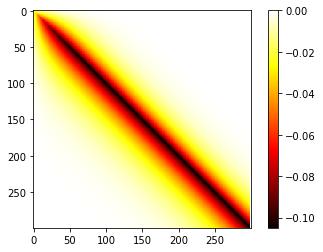

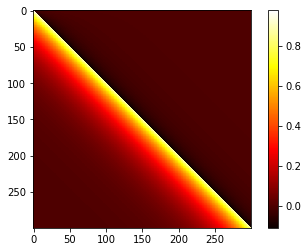

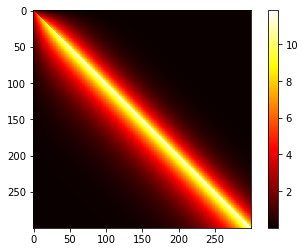

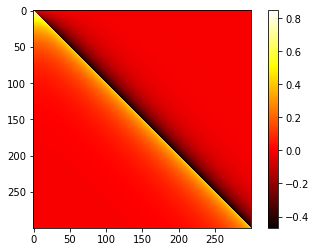

In [359]:
# Note that as we saw already J_firm['r']['K'] already containst the period-ahead response (is off diagonal)
J_curlyK_K = J_ha['A']['r'] @ J_firm['r']['K'] + J_ha['A']['w'] @ J_firm['w']['K']
J_curlyK_Z = J_ha['A']['r'] @ J_firm['r']['Z'] + J_ha['A']['w'] @ J_firm['w']['Z']

print(J_curlyK_K)

# 

plt.imshow(J_curlyK_K , cmap='hot',origin="upper", interpolation='nearest')
plt.colorbar()
plt.show()

plt.imshow(J_curlyK_Z , cmap='hot',origin="upper", interpolation='nearest')
plt.colorbar()
plt.show()

plt.imshow(J_ha['A']['r'] , cmap='hot',origin="upper", interpolation='nearest')
plt.colorbar()
plt.show()

plt.imshow(J_ha['A']['w'] , cmap='hot',origin="upper", interpolation='nearest')
plt.colorbar()
plt.show()

Now, we will combine `J_curlyK_K` and `J_curlyK_Z` with the firm Jacobians to get a single nested dict with the total Jacobians of everything with respect to $K$ and $Z$:

In [321]:
print('------------------')
print('- FIRM BLOCK DICT -')
print('------------------')
J_firm

------------------
- FIRM BLOCK DICT -
------------------


{'r': {'K': SimpleSparse({(-1, 0): -0.010}),
  'Z': SimpleSparse({(0, 0): 0.040})},
 'w': {'K': SimpleSparse({(-1, 0): 0.031}),
  'Z': SimpleSparse({(0, 0): 1.009})},
 'Y': {'K': SimpleSparse({(-1, 0): 0.035}),
  'Z': SimpleSparse({(0, 0): 1.134})}}

In [373]:
J = {**J_firm, 'curlyK': {'K' : J_curlyK_K, 'Z' : J_curlyK_Z}}


print('------------------')
print('- FULL ECON DICT -')
print('------------------')
J


------------------
- FULL ECON DICT -
------------------


{'r': {'K': SimpleSparse({(-1, 0): -0.010}),
  'Z': SimpleSparse({(0, 0): 0.040})},
 'w': {'K': SimpleSparse({(-1, 0): 0.031}),
  'Z': SimpleSparse({(0, 0): 1.009})},
 'Y': {'K': SimpleSparse({(-1, 0): 0.035}),
  'Z': SimpleSparse({(0, 0): 1.134})},
 'curlyK': {'K': array([[-8.19299624e-03, -7.65833325e-03, -7.18403926e-03, ...,
          -8.07507844e-09, -7.70587794e-09,  0.00000000e+00],
         [-1.15073343e-02, -1.54729964e-02, -1.45221857e-02, ...,
          -1.63823846e-08, -1.56333694e-08,  0.00000000e+00],
         [-1.16415500e-02, -1.84282599e-02, -2.20314617e-02, ...,
          -2.49362065e-08, -2.37961095e-08,  0.00000000e+00],
         ...,
         [-5.14758512e-06, -6.56601077e-06, -7.97667047e-06, ...,
          -1.04830676e-01, -9.99653172e-02,  0.00000000e+00],
         [-5.00251556e-06, -6.38097150e-06, -7.75188023e-06, ...,
          -1.04949299e-01, -1.04830676e-01,  0.00000000e+00],
         [-4.86153500e-06, -6.20114753e-06, -7.53342544e-06, ...,
          -1.02

#### Step 3: Invert $H_K$ to obtain impulse response $dK=-H_K^{-1}H_ZdZ$
Now we need to get the Jacobians of our equation $H(K,Z)$, which fully characterizes equilibrium, with respect to $K$ and $Z$. Once we have these, the implicit function theorem gives us the endogenous capital $dK=-H_K^{-1}H_ZdZ$ response to any exogenous shock $dZ$.

Recall that $H$ equals household capital supply $\mathcal{K}$ minus firm capital $K$, so that we can get the Jacobians almost immediately from what we have already calculated.

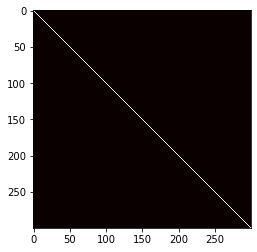

In [351]:
plt.imshow(np.eye(T), cmap='hot', interpolation='nearest')
plt.show()

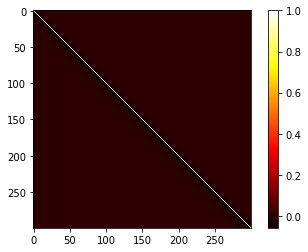

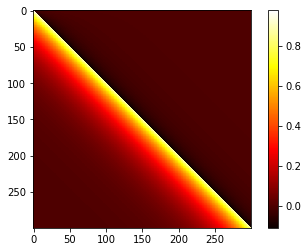

In [355]:
H_K = J['curlyK']['K'] - np.eye(T)
H_Z = J['curlyK']['Z']

plt.imshow(-np.linalg.solve(H_K, np.eye(T)) , cmap='hot',origin="upper", interpolation='nearest')
plt.colorbar()
plt.show()

plt.imshow(H_Z , cmap='hot',origin="upper", interpolation='nearest')
plt.colorbar()
plt.show()

We define $G_K \equiv -H_K^{-1}H_Z$ to be the matrix mapping from any $dZ$ to the corresponding $dK$:
$$dK = G_K dZ$$

In [365]:
G = {'K': -np.linalg.solve(H_K, H_Z)} # H_K^(-1)H_Z
print('Jacobian of K wrt Z')
G

Jacobian of K wrt Z


{'K': array([[ 9.23532603e-01, -6.58692964e-02, -5.77291605e-02, ...,
         -3.00505569e-12, -1.94932042e-12, -8.17670630e-13],
        [ 8.34077529e-01,  8.67109073e-01, -1.16769844e-01, ...,
         -5.72589388e-12, -3.79009600e-12, -1.58808817e-12],
        [ 7.54205747e-01,  7.84634114e-01,  8.22409326e-01, ...,
         -8.28703241e-12, -5.32533358e-12, -2.21780985e-12],
        ...,
        [ 5.18090520e-09,  4.95665329e-09,  4.75965482e-09, ...,
          8.29437182e-01, -1.12725039e-01, -5.70652909e-02],
        [ 5.14036078e-09,  4.92743624e-09,  4.74126123e-09, ...,
          7.92528180e-01,  8.71484906e-01, -6.64882515e-02],
        [ 5.12932931e-09,  4.92599592e-09,  4.74907728e-09, ...,
          7.63342828e-01,  8.39314417e-01,  9.22932287e-01]])}

#### Step 4: Get all other impulses
In `J`'s component from the firm block, we have Jacobians of all other endogenous variables $r,w,Y$ with respect to both $Z$ and $K$. Thus, have that 
$dY(K,Z) = (Y_{Z} + Y_{K} K_{Z}) dZ $ 



In [361]:
J

{'r': {'K': SimpleSparse({(-1, 0): -0.010}),
  'Z': SimpleSparse({(0, 0): 0.040})},
 'w': {'K': SimpleSparse({(-1, 0): 0.031}),
  'Z': SimpleSparse({(0, 0): 1.009})},
 'Y': {'K': SimpleSparse({(-1, 0): 0.035}),
  'Z': SimpleSparse({(0, 0): 1.134})},
 'curlyK': {'K': array([[-8.19299624e-03, -7.65833325e-03, -7.18403926e-03, ...,
          -8.07507844e-09, -7.70587794e-09,  0.00000000e+00],
         [-1.15073343e-02, -1.54729964e-02, -1.45221857e-02, ...,
          -1.63823846e-08, -1.56333694e-08,  0.00000000e+00],
         [-1.16415500e-02, -1.84282599e-02, -2.20314617e-02, ...,
          -2.49362065e-08, -2.37961095e-08,  0.00000000e+00],
         ...,
         [-5.14758512e-06, -6.56601077e-06, -7.97667047e-06, ...,
          -1.04830676e-01, -9.99653172e-02,  0.00000000e+00],
         [-5.00251556e-06, -6.38097150e-06, -7.75188023e-06, ...,
          -1.04949299e-01, -1.04830676e-01,  0.00000000e+00],
         [-4.86153500e-06, -6.20114753e-06, -7.53342544e-06, ...,
          -1.02

If there is a shock to $Z$, we can decompose the change in $r,w,Y$ into a "direct" effect from $dZ$ and an "indirect" effect from the induced change $dK$.

We apply the chain rule to the latter to get matrices $G_r, G_w, G_Y$ mapping any $dZ$ to the corresponding $dr,dw,dY$:

$dY(K,Z) = (G_{Y_{Z}} + G_{Y_{K}} G_{K_{Z}}) dZ $ 

In [368]:
G['r'] = J['r']['Z'] + J['r']['K'] @ G['K']
G['w'] = J['w']['Z'] + J['w']['K'] @ G['K']
G['Y'] = J['Y']['Z'] + J['Y']['K'] @ G['K']
# G is now an expanded dictionary with all reduced-form dynamics
G

{'K': array([[ 9.23532603e-01, -6.58692964e-02, -5.77291605e-02, ...,
         -3.00505569e-12, -1.94932042e-12, -8.17670630e-13],
        [ 8.34077529e-01,  8.67109073e-01, -1.16769844e-01, ...,
         -5.72589388e-12, -3.79009600e-12, -1.58808817e-12],
        [ 7.54205747e-01,  7.84634114e-01,  8.22409326e-01, ...,
         -8.28703241e-12, -5.32533358e-12, -2.21780985e-12],
        ...,
        [ 5.18090520e-09,  4.95665329e-09,  4.75965482e-09, ...,
          8.29437182e-01, -1.12725039e-01, -5.70652909e-02],
        [ 5.14036078e-09,  4.92743624e-09,  4.74126123e-09, ...,
          7.92528180e-01,  8.71484906e-01, -6.64882515e-02],
        [ 5.12932931e-09,  4.92599592e-09,  4.74907728e-09, ...,
          7.63342828e-01,  8.39314417e-01,  9.22932287e-01]]),
 'r': array([[ 3.96984687e-02,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-9.15346746e-03,  4.03513232e-02,  5.72174702e-04, ...,
          2.97841996e-14,  1

The `G` dict characterizes the full linearized dynamics of aggregate variables $K, r, w, Y$ in response to *any* perturbation to $Z$.

If we want the linearized dynamics of other variables, e.g. consumption, all we need is to get the Jacobian from the block in which these are calculated, and then compose it with the `G` of its inputs. It turns out that consumption was already reported in `J_ha`, so we just need to write:

Note again that, just as aggregate $A(r,w)$, so does consumption

$$C = C(r,w)\quad dC = G_{C,Z} dZ $$  
$$ G_{C_{Z}} = (G_{C_{r}}G_{r_{Z}} + G_{C_{w}} G_{w_{Z}})$$

In [378]:
J_ha

{'C': {'r': array([[ 9.57853396e-02, -6.81790147e-01, -6.41199354e-01, ...,
          -7.34063500e-07, -7.00502107e-07, -6.68475062e-07],
         [ 9.41375592e-02,  1.34631530e-01, -6.48415263e-01, ...,
          -7.47833195e-07, -7.13642079e-07, -6.81014312e-07],
         [ 9.25059183e-02,  1.29632227e-01,  1.66519345e-01, ...,
          -7.62691091e-07, -7.27820549e-07, -6.94544368e-07],
         ...,
         [ 3.47837602e-05,  4.04025836e-05,  4.60097133e-05, ...,
           4.78896602e-01, -3.25359881e-01, -3.07241446e-01],
         [ 3.38034487e-05,  3.92639368e-05,  4.47130602e-05, ...,
           4.61175336e-01,  4.78896602e-01, -3.25359881e-01],
         [ 3.28507695e-05,  3.81573842e-05,  4.34529540e-05, ...,
           4.44334027e-01,  4.61175336e-01,  4.78896602e-01]]),
  'w': array([[1.52820583e-01, 4.60843070e-02, 4.18354186e-02, ...,
          3.80864695e-08, 3.63450282e-08, 3.46831151e-08],
         [4.59582841e-02, 1.46606425e-01, 4.20995300e-02, ...,
          3.8800

In [379]:

G['C'] = J_ha['C']['r'] @ G['r'] + J_ha['C']['w'] @ G['w']

### 4.2 Convenient approach: `jacobian.get_G` in one go

All we need to do is give SHADE an H function with a system to clear (root find) in equilibrium (i.e. the targets). 

These steps can be automatized for the entire class of SHADE models. Any SHADE model is characterized by its blocks, exogenous shocks, unknowns to solve for, and targets to clear. The only other things we need to know are the steady state around which to linearize, and the truncation horizon.

If we define a "market clearing" block that returns the target (here, one-dimensional asset market clearing), we can get the general equilibrium Jacobians by simply calling `jacobian.get_G`. Note that `get_G` takes in the model blocks (in arbitrary order), the names of exogenous shocks, the names of unknown endogenous variables, the names of target equations, the truncation horizon, and the steady state dict saved above. 

Note this step is analogous to what we did in solving the REP RBC model where we had a version with two equations to target

`@simple
def mkt_clearing(r, C, Y, I, K, L, w, eis, beta):
    goods_mkt = Y - C - I
    euler = C ** (-1 / eis) - beta * (1 + r(+1)) * C(+1) ** (-1 / eis)
    return goods_mkt, euler, walras`
    
`G = jac.get_G(block_list = [firm, household, mkt_clearing],
              exogenous  = ['Z'],
              unknowns   = ['K', 'L'],
              targets    = ['euler', 'goods_mkt'],
              T          = 300,
                  ss         = ss)`

In [380]:
@simple
def mkt_clearing(K, A):
    asset_mkt = A - K
    return asset_mkt

In [384]:
# Note: we could replace household with J_ha here
G2 = jac.get_G(block_list=[firm, mkt_clearing, household], 
               exogenous=['Z'],
               unknowns=['K'],
               targets=['asset_mkt'],
               T=T, ss=ss)

Let's verify that the two give the same answer up to high precision (`assert` throws an error if its argument evaluates to False).

In [388]:
for o in G:
    assert np.allclose(G2[o]['Z'], G[o])
G2

{'w': {'Z': array([[ 1.00947535e+00,  0.00000000e+00,  0.00000000e+00, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [ 2.87680406e-02,  1.00742352e+00, -1.79826335e-03, ...,
          -9.36074846e-14, -6.07213311e-14, -2.54704401e-14],
         [ 2.59815150e-02,  2.70104476e-02,  1.00583797e+00, ...,
          -1.78361594e-13, -1.18061490e-13, -4.94689465e-14],
         ...,
         [ 1.63518550e-10,  1.56125608e-10,  1.49602403e-10, ...,
           1.00478611e+00, -3.07278297e-03, -1.51987295e-03],
         [ 1.61385197e-10,  1.54399750e-10,  1.48263248e-10, ...,
           2.58369682e-02,  1.00596396e+00, -1.77758381e-03],
         [ 1.60122238e-10,  1.53489639e-10,  1.47690287e-10, ...,
           2.46872528e-02,  2.71467548e-02,  1.00740424e+00]])},
 'C': {'Z': array([[2.10709359e-01, 6.58692964e-02, 5.77291605e-02, ...,
          3.01018879e-12, 1.96209479e-12, 8.37756972e-13],
         [9.86904001e-02, 2.00604900e-01, 5.84633917e-02, ...,
          

### 4.2 Results
What do the impulse responses in this model look like? The beauty of our method is that, now that we have $G$, we can compute impulse responses to any shock almost instantaneously -- it's just matrix multiplication!

Let's first consider shocks to $Z$ with different persistences, all normalized so that they have a 1% initial impact, and plot the interest rate response to each.

As before, we are shocking from the steady state calibrated to start from $Y=1$ and assuming the initial shock size at $t=1$ is common across shocks to be $\Delta = 0.01$ (1% shocks in TFP). 

$ dZ(t) = (\Delta)Z \rho^{t-1}$

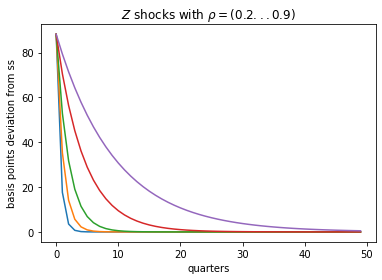

In [392]:
rhos = np.array([0.2, 0.4, 0.6, 0.8, 0.9])

dZ = 0.01*ss['Z']*rhos**(np.arange(T)[:, np.newaxis]) # get T*5 matrix of dZ

dZ.shape

plt.plot(10000*dZ[:50, :])
plt.title(r'$Z$ shocks with $\rho=(0.2 ... 0.9)$')
plt.ylabel(r'basis points deviation from ss')
plt.xlabel(r'quarters')
plt.show()

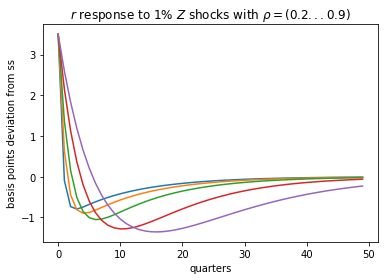

In [393]:
dy = G['r'] @ dZ
plt.plot(10000*dy[:50, :])
plt.title(r'$r$ response to 1% $Z$ shocks with $\rho=(0.2 ... 0.9)$')
plt.ylabel(r'basis points deviation from ss')
plt.xlabel(r'quarters')
plt.show()

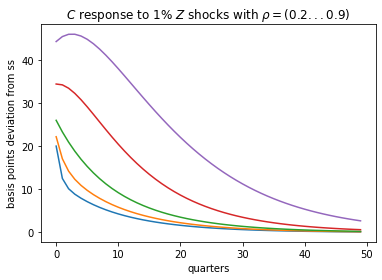

In [395]:
dy = G['C'] @ dZ
plt.plot(10000*dr[:50, :])
plt.title(y'$C$ response to 1% $Z$ shocks with $\rho=(0.2 ... 0.9)$')
plt.ylabel(r'basis points deviation from ss')
plt.xlabel(r'quarters')
plt.show()

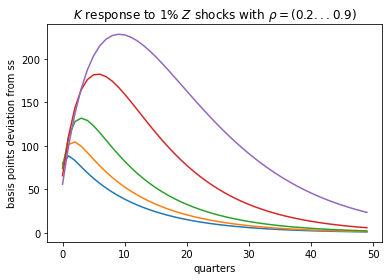

In [398]:
dy = G['K'] @ dZ
plt.plot(10000*dy[:50, :])
plt.title(r'$K$ response to 1% $Z$ shocks with $\rho=(0.2 ... 0.9)$')
plt.ylabel(r'basis points deviation from ss')
plt.xlabel(r'quarters')
plt.show()

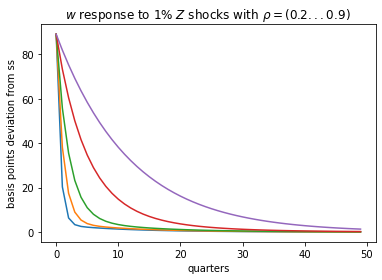

In [399]:
dy = G['w'] @ dZ
plt.plot(10000*dy[:50, :])
plt.title(r'$w$ response to 1% $Z$ shocks with $\rho=(0.2 ... 0.9)$')
plt.ylabel(r'basis points deviation from ss')
plt.xlabel(r'quarters')
plt.show()

Now let's consider 10,000 different values of rho, for which we can still calculate all $r$ impulse responses almost instantaneously.

In [400]:
rhos = np.linspace(0.1, 0.9, 10000)
dZ = 0.01*ss['Z']*rhos**(np.arange(T)[:, np.newaxis]) # get T*5 matrix of dZ
%time dr = G['r'] @ dZ

CPU times: user 89.1 ms, sys: 19.4 ms, total: 109 ms
Wall time: 28.8 ms


The time taken here differs from run to run, but in the current run (like all runs on a personal laptop) it takes less than 50 milliseconds of "wall time" to compute 10,000 impulse responses means that each impulse response takes less than **5 microseconds**. "CPU time" is slightly higher because mild parallelization on two cores is used by the built-in matrix multiplication implementation. By contrast, typical impulse response calculations in heterogeneous agent models in the literature take at least a minute, so this method is more than **10 million** times faster as a way of calculating individual impulse responses.

Although this may seem like an extreme example, repeated calculations of this form are quite useful in the most computationally demanding applications, like estimation (as we will see later). NOTE: there, we are going to want to match IRFs. 

Another important feature of our sequence space methodology is that it is easy to calculate the response to shocks that are difficult to cast into simple recursive form, like news shocks.

For example, calculating the response to a news shock where $Z$ is expected to increase at a specific period in the future is trivial -- in fact, that's exactly what the columns of the $G$ matrix are. Below we plot the capital responses to news shocks of $Z$ increases at periods 5, 10, 15, 20, and 25.

In [408]:
print(np.arange(T).shape)
print(np.array([5, 10, 15, 20, 25]).shape)


(300,)
(5,)


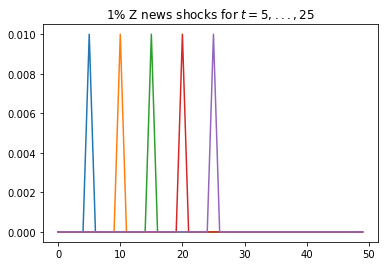

In [406]:
dZ = 0.01*(np.arange(T)[:, np.newaxis] == np.array([5, 10, 15, 20, 25]))
plt.plot(dZ[:50])
plt.title('1% Z news shocks for $t=5,...,25$')
plt.show()

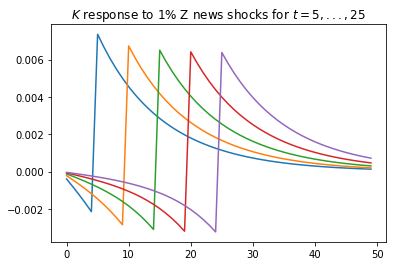

In [409]:
dK = G['K'] @ dZ
plt.plot(dK[:50])
plt.title('$K$ response to 1% Z news shocks for $t=5,...,25$')
plt.show()

<a id="5-estimate"></a>

## 5 Estimation

The roadmap for estimation is as follows:
 - impulse responses $\implies$ second moments
 - second moments $\implies$ log-likelihood
 
In this notebook, we will simply use simulated data to show that the log-likelihood peaks close to the true value of the estimated parameter, the standard deviation of TFP shocks. 

### 5.1 Second moments 
Thanks to certainty equivalence, linear impulse responses can be interpreted as the $MA(\infty)$ representation of the model. Then all we need is the second moments of the shocks to fully characterize the second moments of endogenous outcomes. This computation can be done in a highly efficient way, without any need for simulation.

For concreteness, let's suppose that the TFP shocks $dZ$ in the Krusell-Smith model have a persistent and transitory component.

$$
\begin{align*}
dZ_t &= dZ^1_t + d Z_t^2
\\
dZ_t^1 &= \rho d Z_{t-1}^1 + \epsilon^1_t
\\
d Z_t^2 &= \epsilon^2_t
\end{align*}
$$

where $\epsilon^1$ and $\epsilon^2$ are i.i.d. normal with mean zero and with variance $\sigma^2_1$ and $\sigma^2_2$. 

Let $m^{x, 1}$ and $m^{x,2}$ denote the (truncated) impulse responses of variable $X$ to these two structural shocks. Then we have an $MA(T-1)$ representation:

$$
X_t = \sum_{z=1}^{2} \sum_{s=0}^{T-1} m^{x,z}_s \epsilon_{t-s}^z 
$$

It follows that covariances between outcomes $Y$ and $X$ take the form

$$
\text{Cov}(Y_t, X_{t+l})= \sum_{z=1}^{2} \sigma_z^2 \sum_{s=0}^{T-1} m_s^{x,z} m_{s+l}^{y,z} \tag{Cov}
$$

#### Step 1. Stacked impulse responses

Given the $G$ matrix we calculated in section 4, this is just a matter of matrix multiplication:

In [26]:
rho = 0.9
sigma_persist = 0.1
sigma_trans = 0.2

dZ1 = rho**(np.arange(T))
dY1, dC1, dK1 = G['Y'] @ dZ1, G['C'] @ dZ1, G['K'] @ dZ1
dX1 = np.stack([dZ1, dY1, dC1, dK1], axis=1)

dZ2 = np.arange(T) == 0
dY2, dC2, dK2 = G['Y'] @ dZ2, G['C'] @ dZ2, G['K'] @ dZ2
dX2 = np.stack([dZ2, dY2, dC2, dK2], axis=1)

Let's stack all these to make a $T\times 4 \times 2$ array giving all impulse responses of the four outcomes to the two shocks:

In [27]:
dX = np.stack([dX1, dX2], axis=2)
dX.shape

(300, 4, 2)

#### Step 2. Obtain covariance at all leads and lags

The covariance formula above is implemented efficiently using the Fast Fourier Transform by the `all_covariances` function, which returns a $T\times 4\times 4$ array `Sigma`, where `Sigma[l, o1, o2]` gives the covariance for any $t$ between output `o1` at $t$ and output `o2` at $t+l$.

In [28]:
sigmas = np.array([sigma_persist, sigma_trans])
Sigma = est.all_covariances(dX, sigmas) # burn-in for jit
%time Sigma = est.all_covariances(dX, sigmas)

CPU times: user 932 µs, sys: 9 µs, total: 941 µs
Wall time: 478 µs


#### Visualizing correlations

Let's turn the covariance matrix `Sigma` into a correlation matrix, by normalizing it with the standard deviation of each series:

In [29]:
sd = np.sqrt(np.diag(Sigma[0, ...]))
correl = (Sigma/sd)/(sd[:, np.newaxis])

Finally, let's plot $\text{corr}(dZ_t,dZ_{t+l})$, $\text{corr}(dZ_t,dY_{t+l})$, $\text{corr}(dZ_t,dC_{t+l})$, and $\text{corr}(dZ_t,dK_{t+l})$, for $l$ from $-50$ through $50$: the correlations of all series, at various lags, with the driving productivity process.

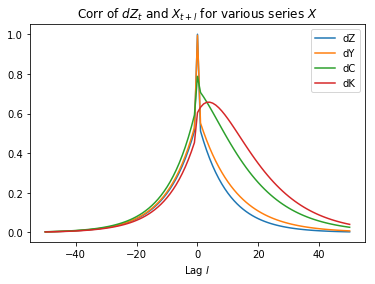

In [30]:
ls = np.arange(-50, 51)
corrs_l_positive = correl[:51, 0, :]
corrs_l_negative = correl[50:0:-1, :, 0]
corrs_combined = np.concatenate([corrs_l_negative, corrs_l_positive])

plt.plot(ls, corrs_combined[:, 0], label='dZ')
plt.plot(ls, corrs_combined[:, 1], label='dY')
plt.plot(ls, corrs_combined[:, 2], label='dC')
plt.plot(ls, corrs_combined[:, 3], label='dK')
plt.legend()
plt.title(r'Corr of $dZ_t$ and $X_{t+l}$ for various series $X$')
plt.xlabel(r'Lag $l$')
plt.show()

Here we can see many features of the solution. First, $dY$ is extremely similar to $dZ$, except that it has a greater lagged response due to capital accumulation. Both $dZ$ and $dY$ have a large peak at $l=0$ corresponding to the transitory shock. $dC$ and $dK$, on the other hand, are both much smoother and tend to lag $dZ$, especially $dK$.

### 5.2 Log-likelihood

Assuming the means of all series are zero (which is often imposed through some kind of preliminary demeaning or detrending procedure on the data), and that the shocks are multivariate normal, all we really need to evaluate the log-likelihood are the second moments and the data.

Specifically, if our data observations are stacked in a vector $\mathbf{y}$ and the covariances at all lags are stacked in a matrix $\mathbf{V}$, then the log-likelihood is (up to a constant):

$$
\mathcal{L} = -\frac{1}{2}\log(\det(\mathbf{V})) - \frac{1}{2}\mathbf{y}'\mathbf{V}^{-1}\mathbf{y} \tag{log-likelihood}
$$ 

Our code proceeds directly from the covariances `Sigma` at all lags returned by `all_covariances` in the last section, and the matrix of data series, implementing (log-likelihood) under the hood to calculate the log-likelihood.

In [31]:
# random 100 observations
Y = np.random.randn(100, 4)

# 0.05 measurement error in each variable
sigma_measurement = np.full(4, 0.05)

# calculate log-likelihood
est.log_likelihood(Y, Sigma, sigma_measurement)

%time est.log_likelihood(Y, Sigma, sigma_measurement)

CPU times: user 3.71 ms, sys: 153 µs, total: 3.87 ms
Wall time: 1.94 ms


-52212.80116916728

### 5.3 Putting it together: calculating the likelihood in an example
Continue to consider the shock process from section 5.1, where $dZ$ had one persistent component and one transitory component. Imagine that we do not know the persistence parameter $\rho$ of the persistent component, nor do we know the relative variances of these two shocks or the variances of the measurement errors. Given some observed data $\mathbf{w}$ with 100 observations of $dZ, dY, dC, dY$, what does the log-likelihood as a function of these parameters look like, and how do we compute it?

We write the following function.

In [32]:
def log_likelihood_from_parameters(rho, sigma_persist, sigma_trans, sigma_measurement, Y):
    # impulse response to persistent shock
    dZ1 = rho**(np.arange(T))
    dY1, dC1, dK1 = G['Y'] @ dZ1, G['C'] @ dZ1, G['K'] @ dZ1
    dX1 = np.stack([dZ1, dY1, dC1, dK1], axis=1)
    
    # since transitory shock does not depend on any unknown parameters,
    # except scale sigma_trans, we just reuse the dX2 already calculated earlier!
    
    # stack impulse responses together to make MA(T-1) representation 'M'
    M = np.stack([dX1, dX2], axis=2)
    
    # calculate all covariances
    Sigma = est.all_covariances(M, np.array([sigma_persist, sigma_trans]))
    
    # calculate log=likelihood from this
    return est.log_likelihood(Y, Sigma, sigma_measurement)

**Simulate sample data.** Now let's simulate more realistic series $w=\{dZ, dY, dC, dK\}$, assuming the same parameters as above, to see what evaluating the log-likelihood is like.

In [33]:
# stack covariances into matrix using helper function, then do a draw using NumPy routine
V = est.build_full_covariance_matrix(Sigma, sigma_measurement, 100)
Y = np.random.multivariate_normal(np.zeros(400), V).reshape((100, 4))

Now let's plot the log-likelihood of $w$ as a function of the standard deviation of the persistent component (the true value of which is 0.1), given correct values for all other parameters. Note that evaluating the log-likelihood 100 times takes well below one second.

In [34]:
sigma_persist_values = np.linspace(0.05, 0.2, 100)
%time lls = np.array([log_likelihood_from_parameters(rho, sigma_persist, sigma_trans, sigma_measurement, Y) for sigma_persist in sigma_persist_values])

CPU times: user 608 ms, sys: 43.3 ms, total: 651 ms
Wall time: 349 ms


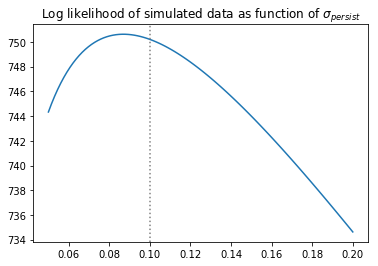

In [35]:
plt.plot(sigma_persist_values, lls)
plt.axvline(0.1, linestyle=':', color='gray')
plt.title(r'Log likelihood of simulated data as function of $\sigma_{persist}$')
plt.show()

Reassuringly, the mode is near (although not exactly at, since we're simulating a finite sample with only 100 periods) the value of $\sigma_{persist}=0.1$ with which the data was simulated!

<a id="7-nonlinear"></a>

## 7 Nonlinear perfect foresight dynamics
Linearized impulse responses are invariant to the sign and size of aggregate shocks by construction. Although this is not a problem for many applications, it is clearly a limitation. Here, we demonstrate that the Jacobian is also extremely useful in solving for nonlinear dynamics.

Consider the case of an economy that starts at the steady state, and receives an unexpected shock at date 0. This is often called an "MIT shock". 

For a given shock $Z$, the solution is still characterized by the $K$ that solves $H(K,Z)=0$. Our algorithm to find this $K$, a simple variant of Newton's method, iterates on a sequence of guesses $K^j$ for the path of capital as follows:
1. starting with $j=0$, guess a path $K^0$
2. calculate $H(K^j, Z)$
3. update the guess according to $$K^{j+1} = K^j - H_K(K_{ss}, Z_{ss})^{-1} H(K^j, Z)$$
and return to step 2 for $j+1$

The only difference between this and the standard Newton's method is that we use the Jacobian $H_K$ around the steady state (which we have already calculated), rather than the Jacobian around the current guess (which is somewhat more difficult to calculate). Still, this tends to achieve extremely fast convergence.

Although iterative methods to solve for equilibrium in response to MIT shocks are quite common in the heterogeneous-agent literature, these methods generally use ad-hoc rules for updating the guess, which can be fragile and slow. In applications with no or limited heterogeneity (such as spender-saver models) where it is possible to calculate Jacobians easily, Newton's method has been used to provide faster and more robust convergence -- see, for instance, [Juillard (1996)](http://www.cepremap.fr/depot/couv_orange/co9602.pdf).

But until now, this has not been applied to heterogeneous-agent models, since the Jacobian has been too difficult to calculate. The only partial applications to date, to our knowledge, are in [Auclert and Rognlie (2018)](http://web.stanford.edu/~aauclert/computational_appendix_inequad.pdf), which uses an auxiliary model to compute an approximate Jacobian, and in [Straub (2018)](https://scholar.harvard.edu/files/straub/files/jmp_straub_jan_2.pdf), which uses interpolation to compute an approximate Jacobian. In this paper, however, we have provided a highly efficient method to compute the *exact* Jacobian around the steady state for any heterogeneous-agent model, and can thus readily apply Newton's method.

Note: Ideally, we'd like to find the value of $K$ that makes $H(K)=0$ at any point in time. We already found one, namely, $H(K_{ss}) = 0$, the steady state, using non-linear methods for root finding.  Newton's method approximates the solution $x_{0}$ to a function $y(x)$ where $y(x_{0})$ using the fact that from a 1st order Taylor expansion, the tangent of the function is
$$ y(x_{1}) = y(x_{0}) + y_{x_{ss}}(x_{1} - x_{0}) $$ 
In essence, it says: well, can we find the point at which the tangent approximating the function crosses zero $y(x)=0$ and check whether this happens at a reasonable point (reasonable in the sense that it converges). 
$$ 0 = y(x_{0}) + y_{x_{ss}}(x_{1} - x_{0}) $$ 
$$ (x_{1} - x_{0})  = -  y_{x_{ss}}^{-1}y(x_{0})$$ 
$$ x_{1} = x_{0} -  y_{x_{ss}}^{-1}y(x_{0})$$ 
In our application of Newton's method, the function we are trying to clear is $y(x) = H(K;Z)$ where Z is a given path of the exogenous variable we take as given.  
And thus, we can update $K_{1}$ iteratively using

$$K_{1} = K_{0} - H_{K}(K_{ss},Z_{ss})^{-1}H(K_{0},Z)$$

And stop when the guess and the implied value are close enough. 

For more info, look at [https://en.wikipedia.org/wiki/Newton%27s_method]

### 7.1 Implementation

As we saw above, we require an steady state Jacobian invered $H_{K_{ss}}^{-1}$, an initial guess for the dynamic path $K_{0}$, and a function that applies $H(K_{0},Z)$

Our quasi-Newton method can be implemented in two steps. First, build the nonlinear function $H(U, Z).$ Second, guess $U$ for a given $Z$ and iterate until convergence. We automatized both of these, so all we need to do is call a single function, `nonlinear.td_solve`.

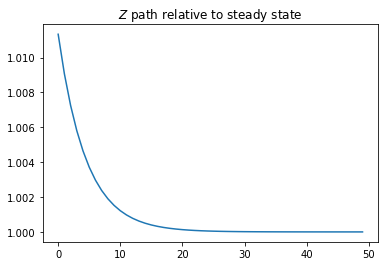

In [414]:
Z = ss['Z'] + 0.01*0.8**np.arange(T)
plt.plot(Z[:50]/ss['Z'])
plt.title('$Z$ path relative to steady state')
plt.show()

In [415]:
# Provide an initial path for Z (note this is in levels Z, not in changes dZ, since the model is solved non-linearly)
Z = ss['Z'] + 0.01*0.8**np.arange(T)

td_nonlin = nonlinear.td_solve(ss        = ss, 
                               block_list= [firm, household, mkt_clearing],
                               unknowns  = ['K'], 
                               targets   = ['asset_mkt'], 
                               H_U       = H_K, 
                               monotonic = True, 
                               Z         = Z)

On iteration 0
   max error for asset_mkt is 3.37E-02
On iteration 1
   max error for asset_mkt is 5.73E-05
On iteration 2
   max error for asset_mkt is 1.26E-07
On iteration 3
   max error for asset_mkt is 1.75E-10


We see that this is quite quick, taking only 3 iterations after the initial guess to achieve high accuracy -- far fewer than typical ad-hoc updating rules, which can take hundreds or even thousands of iterations.

Now let's compare to the results we'd get for the linearized impulse response, and plot the paths for the real interest rate $r$.

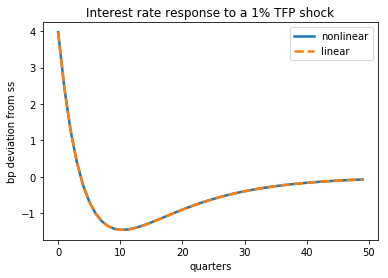

In [37]:
dr_nonlin = 10000 * (td_nonlin['r'] - ss['r'])
dr_lin = 10000 * G['r'] @ (Z - ss['Z'])

plt.plot(dr_nonlin[:50], label='nonlinear', linewidth=2.5)
plt.plot(dr_lin[:50], label='linear', linestyle='--', linewidth=2.5)
plt.title(r'Interest rate response to a 1% TFP shock')
plt.ylabel(r'bp deviation from ss')
plt.xlabel(r'quarters')
plt.legend()
plt.show()

There is no visible difference -- the first-order approximation is almost perfect here.

If we increase the size of the productivity shock on impact to 10% (enormous!), we can begin to see small nonlinearities kick in, and the solution requires five iterations rather than three:

On iteration 0
   max error for asset_mkt is 3.47E-01
On iteration 1
   max error for asset_mkt is 5.22E-03
On iteration 2
   max error for asset_mkt is 1.16E-04
On iteration 3
   max error for asset_mkt is 1.69E-06
On iteration 4
   max error for asset_mkt is 1.13E-08
On iteration 5
   max error for asset_mkt is 2.95E-10


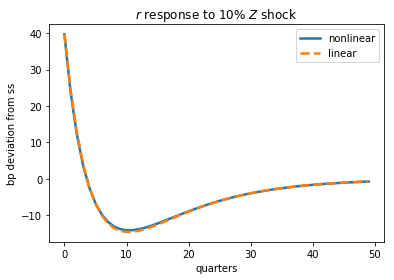

In [38]:
Z = ss['Z'] + 0.1*0.8**np.arange(T)

td_nonlin = nonlinear.td_solve(ss, [firm, household, mkt_clearing], ['K'], ['asset_mkt'], H_K, monotonic=True, Z=Z)

# extract interest rate response, scale to basis points
dr_nonlin = 10000 * (td_nonlin['r'] - ss['r'])
dr_lin = 10000 * G['r'] @ (Z - ss['Z'])

plt.plot(dr_nonlin[:50], label='nonlinear', linewidth=2.5)
plt.plot(dr_lin[:50], label='linear', linestyle='--', linewidth=2.5)
plt.title(r'$r$ response to 10% $Z$ shock')
plt.ylabel(r'bp deviation from ss')
plt.xlabel(r'quarters')
plt.legend()
plt.show()